# Relatório de Performance Completo: Modelo Híbrido LSTM-PINN
## Validação do Treino Robusto e Análise dos Especialistas (2024)

Este notebook realiza uma análise completa do pipeline híbrido de precificação de opções, validando:
1. **Convergência do Treinamento Robusto** (Curriculum Learning + PINN)
2. **Desempenho do Modelo Generalista** em dados out-of-sample 2024
3. **Comparativo entre Generalista vs Especialistas** (Fine-tuning por ativo)
4. **Visualizações 3D da Física Aprendida** (Superfícies de preço e resíduos)

## 1. Carregamento e Configuração do Ambiente

### Configuração do Ambiente e Imports


In [ ]:
#  1: Imports e Configuração de Ambiente
import sys
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset, Subset
from collections import OrderedDict
from datetime import datetime

# Configurações de Plotagem
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

# Adiciona raiz ao path
sys.path.append(os.path.abspath(''))

# Imports do Projeto
from src.config import MODEL_CONFIG, DATA_CONFIG, PATHS, TRAINING_CONFIG, VIZ_CONFIG
from src.model import DeepHestonHybrid, get_activation_function
from src.visualization import Visualizer
from src.data_loader import (
    carregar_taxa_juros, 
    carregar_ibov, 
    _calcular_features_ativo
)

# Configuração de Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo configurado: {device}")

Dispositivo configurado: cuda


### Funções Auxiliares de Carregamento e Processamento

In [ ]:
#  2: Funções Auxiliares de Carregamento

def criar_dataset_periodo(caminho_pasta_opcoes: str, df_juros: pd.DataFrame, 
                         seq_length: int, data_stats: dict, 
                         ano_inicio: int = None, ano_fim: int = None,
                         lstm_input_size: int = 10):
    """
    Gera dataset filtrando por período específico.
    Ajustado para ser compatível com best_model_weights.pth (10 features LSTM)
    """
    lista_dfs = []
    if not os.path.exists(caminho_pasta_opcoes):
        print(f"Erro: Pasta {caminho_pasta_opcoes} não encontrada.")
        return None

    # Carregar IBOV para features
    df_ibov = carregar_ibov(PATHS.get('ibov_data', 
                                     os.path.join(os.path.dirname(caminho_pasta_opcoes), 'BOVA11.csv')))

    print(f"Carregando arquivos de {ano_inicio if ano_inicio else 'todos os anos'}...")
    
    for arquivo in os.listdir(caminho_pasta_opcoes):
        if arquivo.endswith('.csv') and arquivo != "taxa_selic.csv":
            path_completo = os.path.join(caminho_pasta_opcoes, arquivo)
            try:
                df_temp = pd.read_csv(path_completo, sep=';', decimal=',', skiprows=1)
                
                if 'time' in df_temp.columns:
                    df_temp['time'] = pd.to_datetime(df_temp['time'], errors='coerce', utc=True).dt.tz_localize(None)
                
                # Filtro por período
                if ano_inicio is not None:
                    df_temp = df_temp[df_temp['time'].dt.year >= ano_inicio]
                if ano_fim is not None:
                    df_temp = df_temp[df_temp['time'].dt.year <= ano_fim]
                    
                if df_temp.empty: 
                    continue

                if 'ativo' not in df_temp.columns:
                    df_temp['ativo'] = df_temp['symbol'].str[:4] if 'symbol' in df_temp.columns else 'UNKNOWN'
                
                cols_req = ['time', 'spot_price', 'strike', 'premium', 'days_to_maturity', 'ativo']
                if all(c in df_temp.columns for c in cols_req):
                    lista_dfs.append(df_temp[cols_req])
            except Exception as e:
                continue

    if not lista_dfs:
        print(f"Nenhum dado encontrado para o período especificado.")
        return None

    df_full = pd.concat(lista_dfs, ignore_index=True)
    df_full = df_full[df_full['premium'] > 0.0]
    
    # Merges
    df_full['data_only'] = df_full['time'].dt.normalize()
    if df_juros is not None:
        df_full = pd.merge(df_full, df_juros, on='data_only', how='left')
        df_full['r'] = df_full['r'].ffill().bfill().fillna(0.10)
    else:
        df_full['r'] = 0.10
    
    df_full['Dividend_Yield'] = 0.0 

    if df_ibov is not None:
        df_full = pd.merge(df_full, df_ibov, on='data_only', how='left')
        df_full['log_ret_ibov'] = df_full['log_ret_ibov'].fillna(0.0)
    else:
        df_full['log_ret_ibov'] = 0.0

    asset_map = data_stats['asset_map']
    sequences, pinn_inputs, targets, timestamps, asset_ids_list, weights_list = [], [], [], [], [], []
    
    print("Gerando sequências...")
    for nome_ativo, df_grupo in df_full.groupby('ativo'):
        if nome_ativo not in asset_map: 
            continue
        
        asset_id = asset_map[nome_ativo]
        df_grupo = df_grupo.sort_values('time')
        
        df_asset = df_grupo[['time', 'spot_price']].drop_duplicates('time').copy()
        if len(df_asset) < seq_length: 
            continue
        
        df_asset = _calcular_features_ativo(df_asset)
        
        # Criar coluna 'data_only' antes do merge
        df_asset['data_only'] = df_asset['time'].dt.normalize()
        
        if df_ibov is not None:
            df_asset = pd.merge(df_asset, df_ibov, on='data_only', how='left')
            df_asset['log_ret_ibov'] = df_asset['log_ret_ibov'].fillna(0.0)
        else:
            df_asset['log_ret_ibov'] = 0.0
        
        # FEATURES PARA LSTM - COMPATÍVEL COM best_model_weights.pth (10 features)
        # 6 features originais
        cols_lstm_base = ['log_ret', 'rolling_vol_20', 'ewma_vol', 
                         'vol_parkinson', 'log_vol_fin', 'log_ret_ibov']
        
        # Adicionar features adicionais para atingir 10
        for c in cols_lstm_base:
            if c not in df_asset.columns: 
                df_asset[c] = 0.0
        
        # Criar mais 4 features adicionais (duplicar algumas ou criar novas)
        df_asset['rolling_vol_10'] = df_asset['rolling_vol_20'].rolling(10, min_periods=1).mean()
        df_asset['log_ret_squared'] = df_asset['log_ret'] ** 2
        df_asset['vol_ratio'] = df_asset['rolling_vol_20'] / (df_asset['ewma_vol'] + 1e-8)
        df_asset['ibov_vol_ratio'] = df_asset['log_ret_ibov'].abs().rolling(20, min_periods=1).mean()
        
        # Selecionar as 10 features
        if lstm_input_size == 10:
            cols_lstm = cols_lstm_base + ['rolling_vol_10', 'log_ret_squared', 
                                         'vol_ratio', 'ibov_vol_ratio']
        else:
            cols_lstm = cols_lstm_base[:lstm_input_size]
            
        asset_feats = df_asset[cols_lstm].values.astype(np.float32)
        asset_dates = df_asset['time'].tolist()
        date_map = {ts: i for i, ts in enumerate(asset_dates)}
        
        for row in df_grupo.itertuples():
            idx = date_map.get(row.time)
            if idx is not None and idx >= seq_length:
                sequences.append(asset_feats[idx-seq_length : idx])
                
                # 5 features físicas: [S, K, T, r, q]
                pinn_inputs.append([row.spot_price, row.strike, row.days_to_maturity/252.0, 
                                   row.r, row.Dividend_Yield])
                
                targets.append(row.premium)
                timestamps.append(row.time.timestamp())
                asset_ids_list.append(asset_id)
                weights_list.append(1.0)

    if not targets: 
        return None

    # Conversão e Normalização (Z-Score com stats do Treino)
    X_seq = np.array(sequences, dtype=np.float32)
    X_phy = np.array(pinn_inputs, dtype=np.float32)
    y = np.array(targets, dtype=np.float32).reshape(-1, 1)
    
    y_norm = y / (X_phy[:, 1:2] + 1e-8)
    
    # Normalizar 5 features físicas
    X_phy[:, 0] = (X_phy[:, 0] - data_stats['S_mean']) / (data_stats['S_std'] + 1e-8)
    X_phy[:, 1] = (X_phy[:, 1] - data_stats['K_mean']) / (data_stats['K_std'] + 1e-8)
    X_phy[:, 2] = (X_phy[:, 2] - data_stats['T_mean']) / (data_stats['T_std'] + 1e-8)
    X_phy[:, 3] = (X_phy[:, 3] - data_stats['r_mean']) / (data_stats['r_std'] + 1e-8)
    X_phy[:, 4] = (X_phy[:, 4] - data_stats['q_mean']) / (data_stats['q_std'] + 1e-8)

    print(f"Dataset Gerado: {len(y)} amostras com {X_seq.shape[2]} features LSTM.")
    return TensorDataset(
        torch.from_numpy(X_seq), torch.from_numpy(X_phy), torch.from_numpy(y_norm),
        torch.from_numpy(np.array(timestamps, dtype=np.float64).reshape(-1,1)), 
        torch.from_numpy(np.array(weights_list, dtype=np.float32).reshape(-1,1)), 
        torch.from_numpy(np.array(asset_ids_list, dtype=np.int64))
    )

In [ ]:
#  3: Função para Reconstrução Dinâmica do Modelo

def load_adaptive_model(model_class, config, data_stats, checkpoint_path, device):
    """
    Carrega um modelo adaptando a arquitetura às dimensões encontradas no checkpoint.
    """
    print(f"Carregando modelo de: {checkpoint_path}")
    state_dict = torch.load(checkpoint_path, map_location=device)
    
    # Verificar o tamanho real da entrada da LSTM
    if 'lstm.weight_ih_l0' in state_dict:
        weight_ih = state_dict['lstm.weight_ih_l0']
        ckpt_input_size = weight_ih.shape[1]
        print(f"Detectado LSTM input_size no checkpoint: {ckpt_input_size}")
        
        # Ajustar configuração baseada no checkpoint
        config['lstm_input_size'] = ckpt_input_size
        
        # Se o checkpoint tem 10 features, desativar embeddings se necessário
        if ckpt_input_size == 10:
            config['use_asset_embeddings'] = False
            print("  -> Configurado sem embeddings (10 features diretas)")
    
    # Instancia modelo base
    model = model_class(config, data_stats)
    
    # Adaptação da Camada Fourier (Legado)
    if 'fourier_layer.weight' in state_dict:
        fourier_w = state_dict['fourier_layer.weight']
        out_features, in_features = fourier_w.shape
        model.fourier_layer = nn.Linear(in_features, out_features)
        print(f"  -> Camada Fourier reconstruída: {in_features} -> {out_features}")
    
    # Adaptação da PINN (Pricing Net)
    from src.model import AdaptiveActivation
    activation_fn = get_activation_function(config.get('activation', 'tanh'))
    
    # Detecta camadas lineares da PINN
    layer_indices = sorted([int(k.split('.')[1]) for k in state_dict.keys() 
                           if 'pricing_net' in k and 'weight' in k])
    
    if layer_indices:
        print(f"  -> Reconstruindo Pricing Net com {len(layer_indices)} camadas...")
        layers = OrderedDict()
        for i, idx in enumerate(layer_indices):
            weight_key = f'pricing_net.{idx}.weight'
            w_shape = state_dict[weight_key].shape
            
            # Recria camada com dimensões corretas
            layers[str(idx)] = nn.Linear(in_features=w_shape[1], out_features=w_shape[0])
            
            # Adiciona ativação se necessário
            if i < len(layer_indices) - 1:
                act_key = f'pricing_net.{idx+1}.a'
                if act_key in state_dict:
                    layers[str(idx+1)] = AdaptiveActivation(activation_fn)
                else:
                    # Verificar se é camada de ativação ou outra camada linear
                    next_weight_key = f'pricing_net.{idx+1}.weight'
                    if next_weight_key in state_dict:
                        # É outra camada linear, não adicionar ativação aqui
                        pass
                    else:
                        layers[str(idx+1)] = activation_fn
                
        model.pricing_net = nn.Sequential(layers)
    
    # Carregamento dos Pesos
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    
    if missing:
        print(f"Camadas faltando: {missing}")
    if unexpected:
        print(f"Camadas inesperadas: {unexpected}")
    
    if not missing and not unexpected:
        print("Todos os pesos carregados com sucesso")
    
    # Sincronização de device
    model = model.to(device)
    model.eval()
    
    return model

In [ ]:
#  4: Funções de Avaliação Estatística

def calcular_metricas(y_true, y_pred):
    """
    Calcula métricas estatísticas para avaliação do modelo.
    """
    metrics = {}
    
    # Métricas básicas
    metrics['MAE'] = mean_absolute_error(y_true, y_pred)
    metrics['RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))
    metrics['R2'] = r2_score(y_true, y_pred)
    
    # Erro percentual
    errors = np.abs(y_true - y_pred)
    metrics['MAPE'] = np.mean(errors / (np.abs(y_true) + 1e-8)) * 100
    
    # Estatísticas dos erros
    metrics['Erro Médio'] = np.mean(y_pred - y_true)
    metrics['Std Erro'] = np.std(y_pred - y_true)
    
    # Percentis dos erros
    metrics['P25 Erro'] = np.percentile(errors, 25)
    metrics['P50 Erro'] = np.percentile(errors, 50)
    metrics['P75 Erro'] = np.percentile(errors, 75)
    
    # Teste de normalidade dos resíduos
    residuals = y_pred - y_true
    _, p_value = stats.shapiro(residuals[:min(5000, len(residuals))])
    metrics['Shapiro-Wilk p-value'] = p_value
    
    return metrics

def avaliar_modelo(model, loader, data_stats, device, model_name="Modelo"):
    """
    Avalia um modelo em um dataset específico.
    """
    model.eval()
    all_predictions = []
    all_targets = []
    all_vols = []
    
    with torch.no_grad():
        for batch in loader:
            x_seq, x_phy, y_norm, _, _, ids = [b.to(device) for b in batch]
            
            outputs = model(x_seq, x_phy, ids)
            
            # Desnormalizar preços
            K_real = x_phy[:, 1:2] * data_stats['K_std'] + data_stats['K_mean']
            price_pred = outputs['price'] * K_real
            price_real = y_norm * K_real
            
            all_predictions.extend(price_pred.cpu().numpy().flatten())
            all_targets.extend(price_real.cpu().numpy().flatten())
            
            if 'volatility' in outputs:
                all_vols.extend(outputs['volatility'].cpu().numpy().flatten())
    
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)
    
    # Calcular métricas
    metrics = calcular_metricas(all_targets, all_predictions)
    
    print(f"\n{'='*60}")
    print(f"AVALIAÇÃO: {model_name}")
    print(f"{'='*60}")
    print(f"Amostras avaliadas: {len(all_targets):,}")
    print(f"MAE: {metrics['MAE']:.4f}")
    print(f"RMSE: {metrics['RMSE']:.4f}")
    print(f"R²: {metrics['R2']:.4f}")
    print(f"MAPE: {metrics['MAPE']:.2f}%")
    print(f"Erro Médio: {metrics['Erro Médio']:.4f}")
    print(f"Std Erro: {metrics['Std Erro']:.4f}")
    
    if all_vols:
        print(f"Volatilidade Média Estimada: {np.mean(all_vols):.4f}")
    
    return {
        'predictions': all_predictions,
        'targets': all_targets,
        'volatilities': np.array(all_vols) if all_vols else None,
        'metrics': metrics
    }

In [ ]:
#  5: Funções de Visualização - ATUALIZAR plot_training_history

def plot_training_history(history_path):
    """
    Plota o histórico de treinamento a partir do arquivo CSV.
    ATUALIZADO: Inclui avg_pred_vol, avg_pred_price, avg_real_price
    """
    if not os.path.exists(history_path):
        print(f"Arquivo de histórico não encontrado: {history_path}")
        return None
    
    history_df = pd.read_csv(history_path)
    history_df['epoch'] = range(1, len(history_df) + 1)

    fig, axes = plt.subplots(2, 4, figsize=(24, 12))  # Alterado para 2x4
    
    # Loss Total
    axes[0, 0].plot(history_df['epoch'], history_df['train_loss'], label='Total Loss', linewidth=2)
    axes[0, 0].set_xlabel('Época')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Evolução da Loss Total')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    # Loss de Dados
    axes[0, 1].plot(history_df['epoch'], history_df['loss_data'], label='Data Loss', linewidth=2)
    axes[0, 1].set_xlabel('Época')
    axes[0, 1].set_ylabel('Data Loss')
    axes[0, 1].set_title('Loss de Dados')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    
    # Loss da PDE
    axes[0, 2].plot(history_df['epoch'], history_df['loss_pde'], label='PDE Loss', linewidth=2, color='red')
    axes[0, 2].set_xlabel('Época')
    axes[0, 2].set_ylabel('PDE Loss')
    axes[0, 2].set_title('Loss da Equação de Heston')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].legend()
    
    # Learning Rate
    axes[0, 3].plot(history_df['epoch'], history_df['lr'], label='Learning Rate', linewidth=2, color='green')
    axes[0, 3].set_xlabel('Época')
    axes[0, 3].set_ylabel('Learning Rate')
    axes[0, 3].set_title('Evolução do Learning Rate')
    axes[0, 3].grid(True, alpha=0.3)
    axes[0, 3].set_yscale('log')
    axes[0, 3].legend()
    
    # MAE de Validação
    axes[1, 0].plot(history_df['epoch'], history_df['val_mae'], label='Val MAE', linewidth=2, color='purple')
    axes[1, 0].set_xlabel('Época')
    axes[1, 0].set_ylabel('MAE')
    axes[1, 0].set_title('MAE de Validação')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    # Volatilidade Média Prevista (se existir)
    if 'avg_pred_vol' in history_df.columns:
        axes[1, 1].plot(history_df['epoch'], history_df['avg_pred_vol'], label='Vol Prevista', linewidth=2, color='orange')
        axes[1, 1].set_xlabel('Época')
        axes[1, 1].set_ylabel('Volatilidade')
        axes[1, 1].set_title('Volatilidade Média Prevista')
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].legend()
    else:
        axes[1, 1].text(0.5, 0.5, 'Dados não disponíveis\n(avg_pred_vol)', 
                       horizontalalignment='center', verticalalignment='center',
                       transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Volatilidade Média Prevista')
    
    # Preço Médio Previsto vs Real
    if 'avg_pred_price' in history_df.columns and 'avg_real_price' in history_df.columns:
        axes[1, 2].plot(history_df['epoch'], history_df['avg_pred_price'], label='Preço Previsto', 
                       linewidth=2, color='blue')
        axes[1, 2].plot(history_df['epoch'], history_df['avg_real_price'], label='Preço Real', 
                       linewidth=2, color='red', linestyle='--')
        axes[1, 2].set_xlabel('Época')
        axes[1, 2].set_ylabel('Preço')
        axes[1, 2].set_title('Preço Médio: Previsto vs Real')
        axes[1, 2].grid(True, alpha=0.3)
        axes[1, 2].legend()
    else:
        axes[1, 2].text(0.5, 0.5, 'Dados não disponíveis\n(avg_pred_price/avg_real_price)', 
                       horizontalalignment='center', verticalalignment='center',
                       transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Preço Médio: Previsto vs Real')
    
       
    plt.tight_layout()
    plt.savefig(os.path.join(PATHS['model_save_dir'], 'training_history_plots.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Análise estatística do treinamento
    print("\nANÁLISE DO TREINAMENTO:")
    print("="*50)
    print(f"Número total de épocas: {len(history_df)}")
    print(f"Loss total final: {history_df['train_loss'].iloc[-1]:.6f}")
    print(f"Loss de dados final: {history_df['loss_data'].iloc[-1]:.6f}")
    print(f"Loss PDE final: {history_df['loss_pde'].iloc[-1]:.6f}")
    print(f"MAE de validação final: {history_df['val_mae'].iloc[-1]:.6f}")
    
    if 'avg_pred_vol' in history_df.columns:
        print(f"Volatilidade média final: {history_df['avg_pred_vol'].iloc[-1]:.6f}")
    if 'avg_pred_price' in history_df.columns and 'avg_real_price' in history_df.columns:
        print(f"Preço médio previsto final: {history_df['avg_pred_price'].iloc[-1]:.6f}")
        print(f"Preço médio real final: {history_df['avg_real_price'].iloc[-1]:.6f}")
    if 'val_r2' in history_df.columns:
        print(f"R² de validação final: {history_df['val_r2'].iloc[-1]:.6f}")
    
    print(f"Learning Rate final: {history_df['lr'].iloc[-1]:.6e}")
    
    return history_df

## 2. Análise do Modelo Robusto (Generalista)

In [ ]:
#  6: Carregamento de Dados e Configurações

print("PARTE 2: ANÁLISE DO MODELO GENERALISTA")

# Carregar stats de normalização
stats_path = os.path.join(PATHS['model_save_dir'], 'data_stats.json')
with open(stats_path, 'r') as f:
    data_stats = json.load(f)

# Atualizar num_assets
MODEL_CONFIG['num_assets'] = len(data_stats['asset_map'])
print(f"Ativos no modelo: {MODEL_CONFIG['num_assets']}")
print(f"Mapa de ativos: {list(data_stats['asset_map'].keys())}")

# Primeiro, carregar o modelo para verificar o input_size esperado
weights_path = os.path.join(PATHS['model_save_dir'], 'best_model_weights.pth')
state_dict = torch.load(weights_path, map_location=device)

# Determinar input_size do checkpoint
if 'lstm.weight_ih_l0' in state_dict:
    weight_ih = state_dict['lstm.weight_ih_l0']
    lstm_input_size = weight_ih.shape[1]
    print(f"\nInput size detectado no checkpoint: {lstm_input_size}")
else:
    lstm_input_size = MODEL_CONFIG.get('lstm_input_size', 6)
    print(f"\nInput size da configuração: {lstm_input_size}")

# Carregar dados de juros
df_juros = carregar_taxa_juros(PATHS['selic_data'])
pasta_dados = os.path.join(PATHS['raw_data'])

# Criar datasets para diferentes períodos com o input_size correto
print("\nCriando datasets...")
ds_treino = criar_dataset_periodo(pasta_dados, df_juros, 
                                  DATA_CONFIG['sequence_length'], 
                                  data_stats, 2020, 2023,
                                  lstm_input_size=lstm_input_size)

ds_2024 = criar_dataset_periodo(pasta_dados, df_juros,
                               DATA_CONFIG['sequence_length'],
                               data_stats, 2024, 2024,
                               lstm_input_size=lstm_input_size)

if ds_treino and ds_2024:
    print(f"\nResumo dos Datasets:")
    print(f"  Treino (2020-2023): {len(ds_treino):,} amostras")
    print(f"  Validação (2024): {len(ds_2024):,} amostras")
    
    # Verificar shape das sequências
    sample_batch = next(iter(DataLoader(ds_2024, batch_size=1)))
    x_seq_sample = sample_batch[0]
    print(f"\nVerificação de shape:")
    print(f"  Sequência LSTM: {x_seq_sample.shape}")
    print(f"  Features por timestep: {x_seq_sample.shape[2]}")
    print(f"  Esperado pelo modelo: {lstm_input_size}")
    
    if x_seq_sample.shape[2] != lstm_input_size:
        print(f"AVISO: Mismatch entre dataset ({x_seq_sample.shape[2]}) e modelo ({lstm_input_size})")
else:
    print("Erro: Não foi possível criar os datasets")
    raise SystemExit

print("\nCarregando modelo generalista...")
weights_path = os.path.join(PATHS['model_save_dir'], 'best_model_weights.pth')

if not os.path.exists(weights_path):
    print(f"ERRO: Arquivo de pesos não encontrado: {weights_path}")
    raise FileNotFoundError(f"Pesos do modelo não encontrados em {weights_path}")

# Criar e carregar modelo adaptativo
model_generalista = load_adaptive_model(
    DeepHestonHybrid,
    MODEL_CONFIG,
    data_stats,
    weights_path,
    device
)

print("Modelo generalista carregado com sucesso!")

PARTE 2: ANÁLISE DO MODELO GENERALISTA
Ativos no modelo: 14
Mapa de ativos: ['ABEV', 'B3SA', 'BBAS', 'BBDC', 'BOVA', 'CSNA', 'GGBR', 'ITUB', 'LREN', 'MGLU', 'PETR', 'SUZB', 'VALE', 'WEGE']

Input size detectado no checkpoint: 10

Criando datasets...
[INFO] IBOV carregado com sucesso: 443085 registros, coluna de preço: acao_close_ajustado
Carregando arquivos de 2020...
Gerando sequências...
Dataset Gerado: 2277735 amostras com 10 features LSTM.
[INFO] IBOV carregado com sucesso: 443085 registros, coluna de preço: acao_close_ajustado
Carregando arquivos de 2024...
Gerando sequências...
Dataset Gerado: 736451 amostras com 10 features LSTM.

Resumo dos Datasets:
  Treino (2020-2023): 2,277,735 amostras
  Validação (2024): 736,451 amostras

Verificação de shape:
  Sequência LSTM: torch.Size([1, 30, 10])
  Features por timestep: 10
  Esperado pelo modelo: 10

Carregando modelo generalista...
Carregando modelo de: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\modelo_final\best_model

In [ ]:
#  6.1: Função de Backtest para Modelo Generalista

def plot_backtest_2024(results, title="Backtest 2024 - Modelo Generalista"):
    """
    Plota resultados de backtest para 2024 com análise temporal.
    """
    predictions = results['predictions']
    targets = results['targets']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Scatter Plot Previsões vs Real
    axes[0, 0].scatter(targets[:5000], predictions[:5000], alpha=0.5, s=10)
    max_val = max(targets.max(), predictions.max())
    min_val = min(targets.min(), predictions.min())
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    axes[0, 0].set_xlabel('Valor Real (Premium)')
    axes[0, 0].set_ylabel('Valor Previsto')
    axes[0, 0].set_title(f'Previsões vs Real\nR²: {results["metrics"]["R2"]:.3f}, MAE: {results["metrics"]["MAE"]:.3f}')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Distribuição de Erros
    errors = predictions - targets
    axes[0, 1].hist(errors, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel('Erro (Previsto - Real)')
    axes[0, 1].set_ylabel('Frequência')
    axes[0, 1].set_title('Distribuição dos Erros')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Erro Percentual por Faixa de Preço
    price_bins = np.linspace(targets.min(), targets.max(), 10)
    bin_errors = []
    bin_centers = []
    
    for i in range(len(price_bins)-1):
        mask = (targets >= price_bins[i]) & (targets < price_bins[i+1])
        if mask.sum() > 0:
            bin_errors.append(np.mean(np.abs(errors[mask]) / (targets[mask] + 1e-8)) * 100)
            bin_centers.append((price_bins[i] + price_bins[i+1]) / 2)
    
    axes[0, 2].bar(bin_centers, bin_errors, width=price_bins[1]-price_bins[0], 
                   alpha=0.7, color='green', edgecolor='black')
    axes[0, 2].set_xlabel('Faixa de Preço Real')
    axes[0, 2].set_ylabel('MAPE (%)')
    axes[0, 2].set_title('Erro Percentual por Faixa de Preço')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Evolução Temporal dos Erros (se timestamps disponíveis)
    if 'timestamps' in results:
        timestamps = pd.to_datetime(results['timestamps'], unit='s')
        df_temporal = pd.DataFrame({
            'date': timestamps,
            'error': errors,
            'price': targets
        })
        
        # Agrupa por dia
        df_daily = df_temporal.groupby(df_temporal['date'].dt.date).agg({
            'error': 'mean',
            'price': 'count'
        }).reset_index()
        
        axes[1, 0].plot(df_daily['date'], df_daily['error'], 'b-', linewidth=1.5)
        axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=1)
        axes[1, 0].set_xlabel('Data')
        axes[1, 0].set_ylabel('Erro Médio Diário')
        axes[1, 0].set_title('Evolução do Erro ao Longo do Tempo')
        axes[1, 0].tick_params(axis='x', rotation=45)
        axes[1, 0].grid(True, alpha=0.3)
    
    # QQ-Plot dos Resíduos
    import statsmodels.api as sm
    sm.qqplot(errors[:5000], line='45', ax=axes[1, 1])
    axes[1, 1].set_title('QQ-Plot dos Resíduos')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Volatilidade Estimada vs Erro (se disponível)
    if results['volatilities'] is not None:
        vol = results['volatilities']
        axes[1, 2].scatter(vol[:5000], np.abs(errors[:5000]), alpha=0.3, s=10)
        axes[1, 2].set_xlabel('Volatilidade Estimada')
        axes[1, 2].set_ylabel('Erro Absoluto')
        axes[1, 2].set_title('Erro vs Volatilidade Estimada')
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(PATHS['model_save_dir'], 'backtest_2024_generalista.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()

### Histórico de Treinamento


ANÁLISE DO HISTÓRICO DE TREINAMENTO


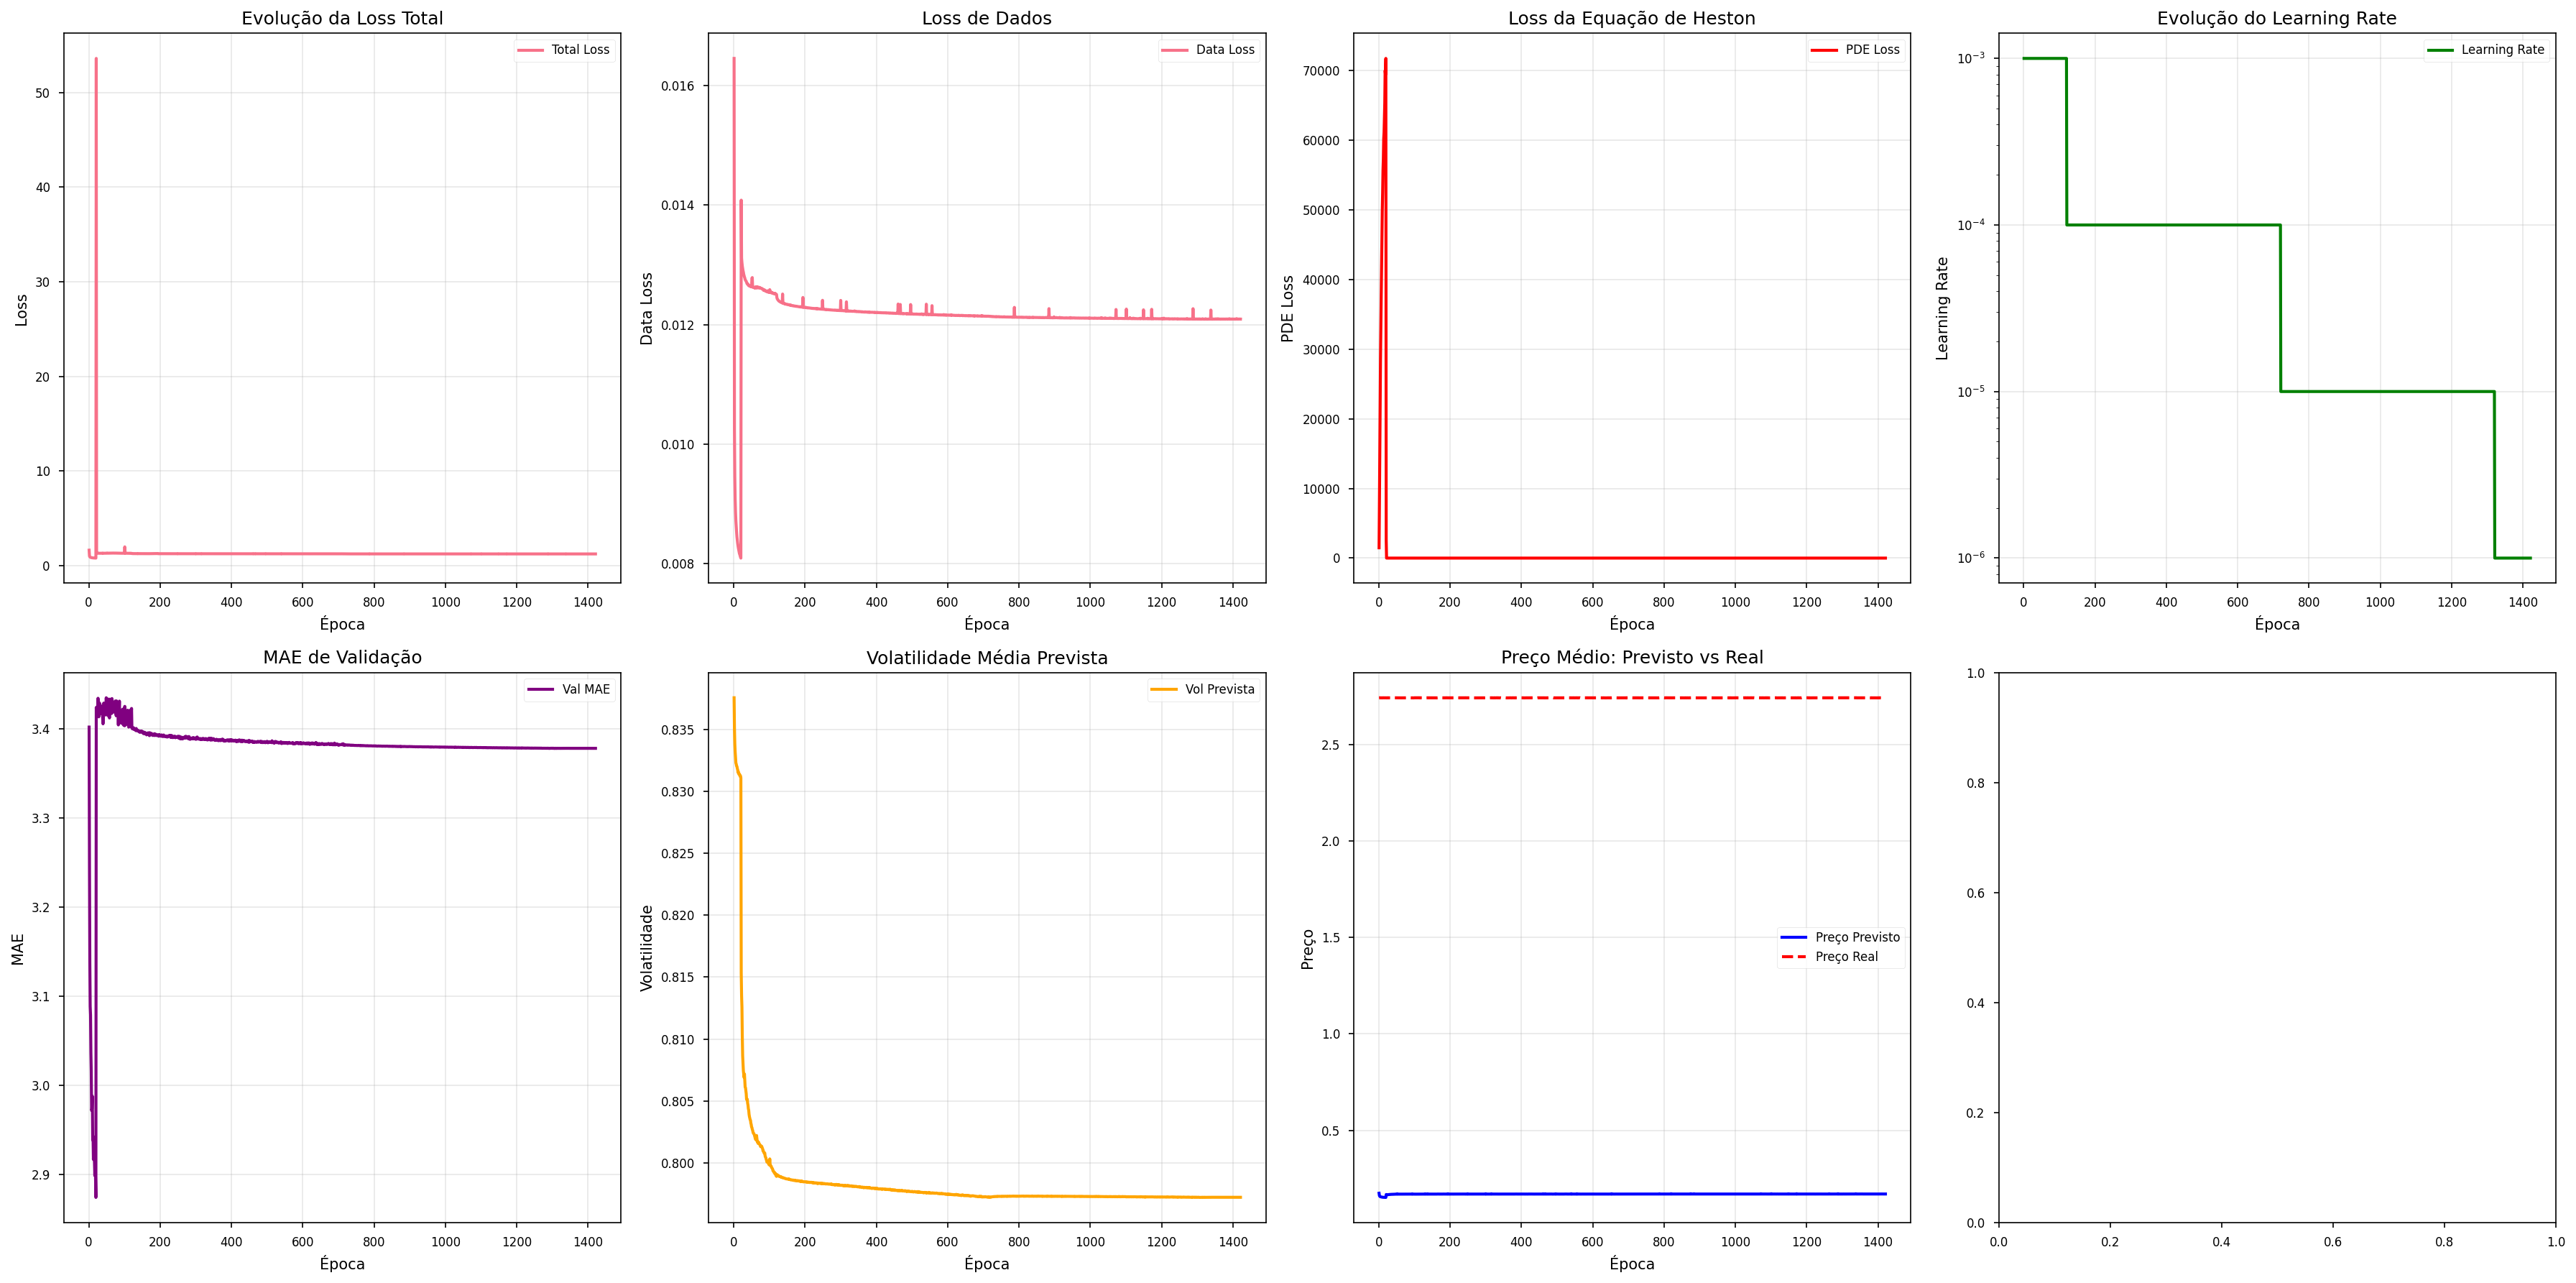


ANÁLISE DO TREINAMENTO:
Número total de épocas: 1421
Loss total final: 1.249120
Loss de dados final: 0.012092
Loss PDE final: 0.039903
MAE de validação final: 3.378413
Volatilidade média final: 0.797238
Preço médio previsto final: 0.169723
Preço médio real final: 2.743532
Learning Rate final: 1.000000e-06

ANÁLISE DE CONVERGÊNCIA:
----------------------------------------
Treinamento estável (MAE de validação decrescente ou estável)


In [ ]:
#  7: Análise do Histórico de Treinamento

print("\n" + "="*70)
print("ANÁLISE DO HISTÓRICO DE TREINAMENTO")
print("="*70)

history_path = os.path.join(PATHS['results_dir'], 'training_history.csv')
if os.path.exists(history_path):
    history_df = plot_training_history(history_path)
    
    # Análise adicional da convergência
    print("\nANÁLISE DE CONVERGÊNCIA:")
    print("-"*40)
    
    # Verificar se houve overfitting
    if 'val_mae' in history_df.columns:
        if len(history_df) > 10:
            val_mae_trend = history_df['val_mae'].iloc[-10:].diff().mean()
            if val_mae_trend > 0:
                print("Possível overfitting detectado (MAE de validação aumentando)")
            else:
                print("Treinamento estável (MAE de validação decrescente ou estável)")
    
    # Verificar convergência da PDE
    if 'pde_loss' in history_df.columns:
        pde_loss_final = history_df['pde_loss'].iloc[-1]
        if pde_loss_final < 0.01:
            print("PDE bem satisfeita (loss < 0.01)")
        elif pde_loss_final < 0.1:
            print("PDE moderadamente satisfeita (loss < 0.1)")
        else:
            print("PDE não satisfeita adequadamente")
    
    # Análise do curriculum learning
    if 'curriculum_stage' in history_df.columns:
        print(f"\nCurriculum Learning:")
        stages = history_df['curriculum_stage'].unique()
        print(f"  Estágios utilizados: {len(stages)}")
        for stage in sorted(stages):
            stage_data = history_df[history_df['curriculum_stage'] == stage]
            print(f"  Estágio {stage}: Épocas {stage_data.index.min()}-{stage_data.index.max()}, "
                  f"Loss final: {stage_data['total_loss'].iloc[-1]:.6f}")
        
else:
    print("Arquivo de histórico de treinamento não encontrado.")

### Carregamento do Modelo Generalista e Dados 2024


PARTE 2: AVALIAÇÃO DO MODELO GENERALISTA EM 2024
Carregando modelo de: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\modelo_final\best_model_weights.pth
Detectado LSTM input_size no checkpoint: 10
  -> Configurado sem embeddings (10 features diretas)
  -> Reconstruindo Pricing Net com 5 camadas...
Camadas inesperadas: ['asset_embedding.weight']

AVALIAÇÃO: Generalista (2024)
Amostras avaliadas: 736,451
MAE: 5.1418
RMSE: 11.5865
R²: -1.0894
MAPE: 6844.69%
Erro Médio: -1.1543
Std Erro: 11.5288


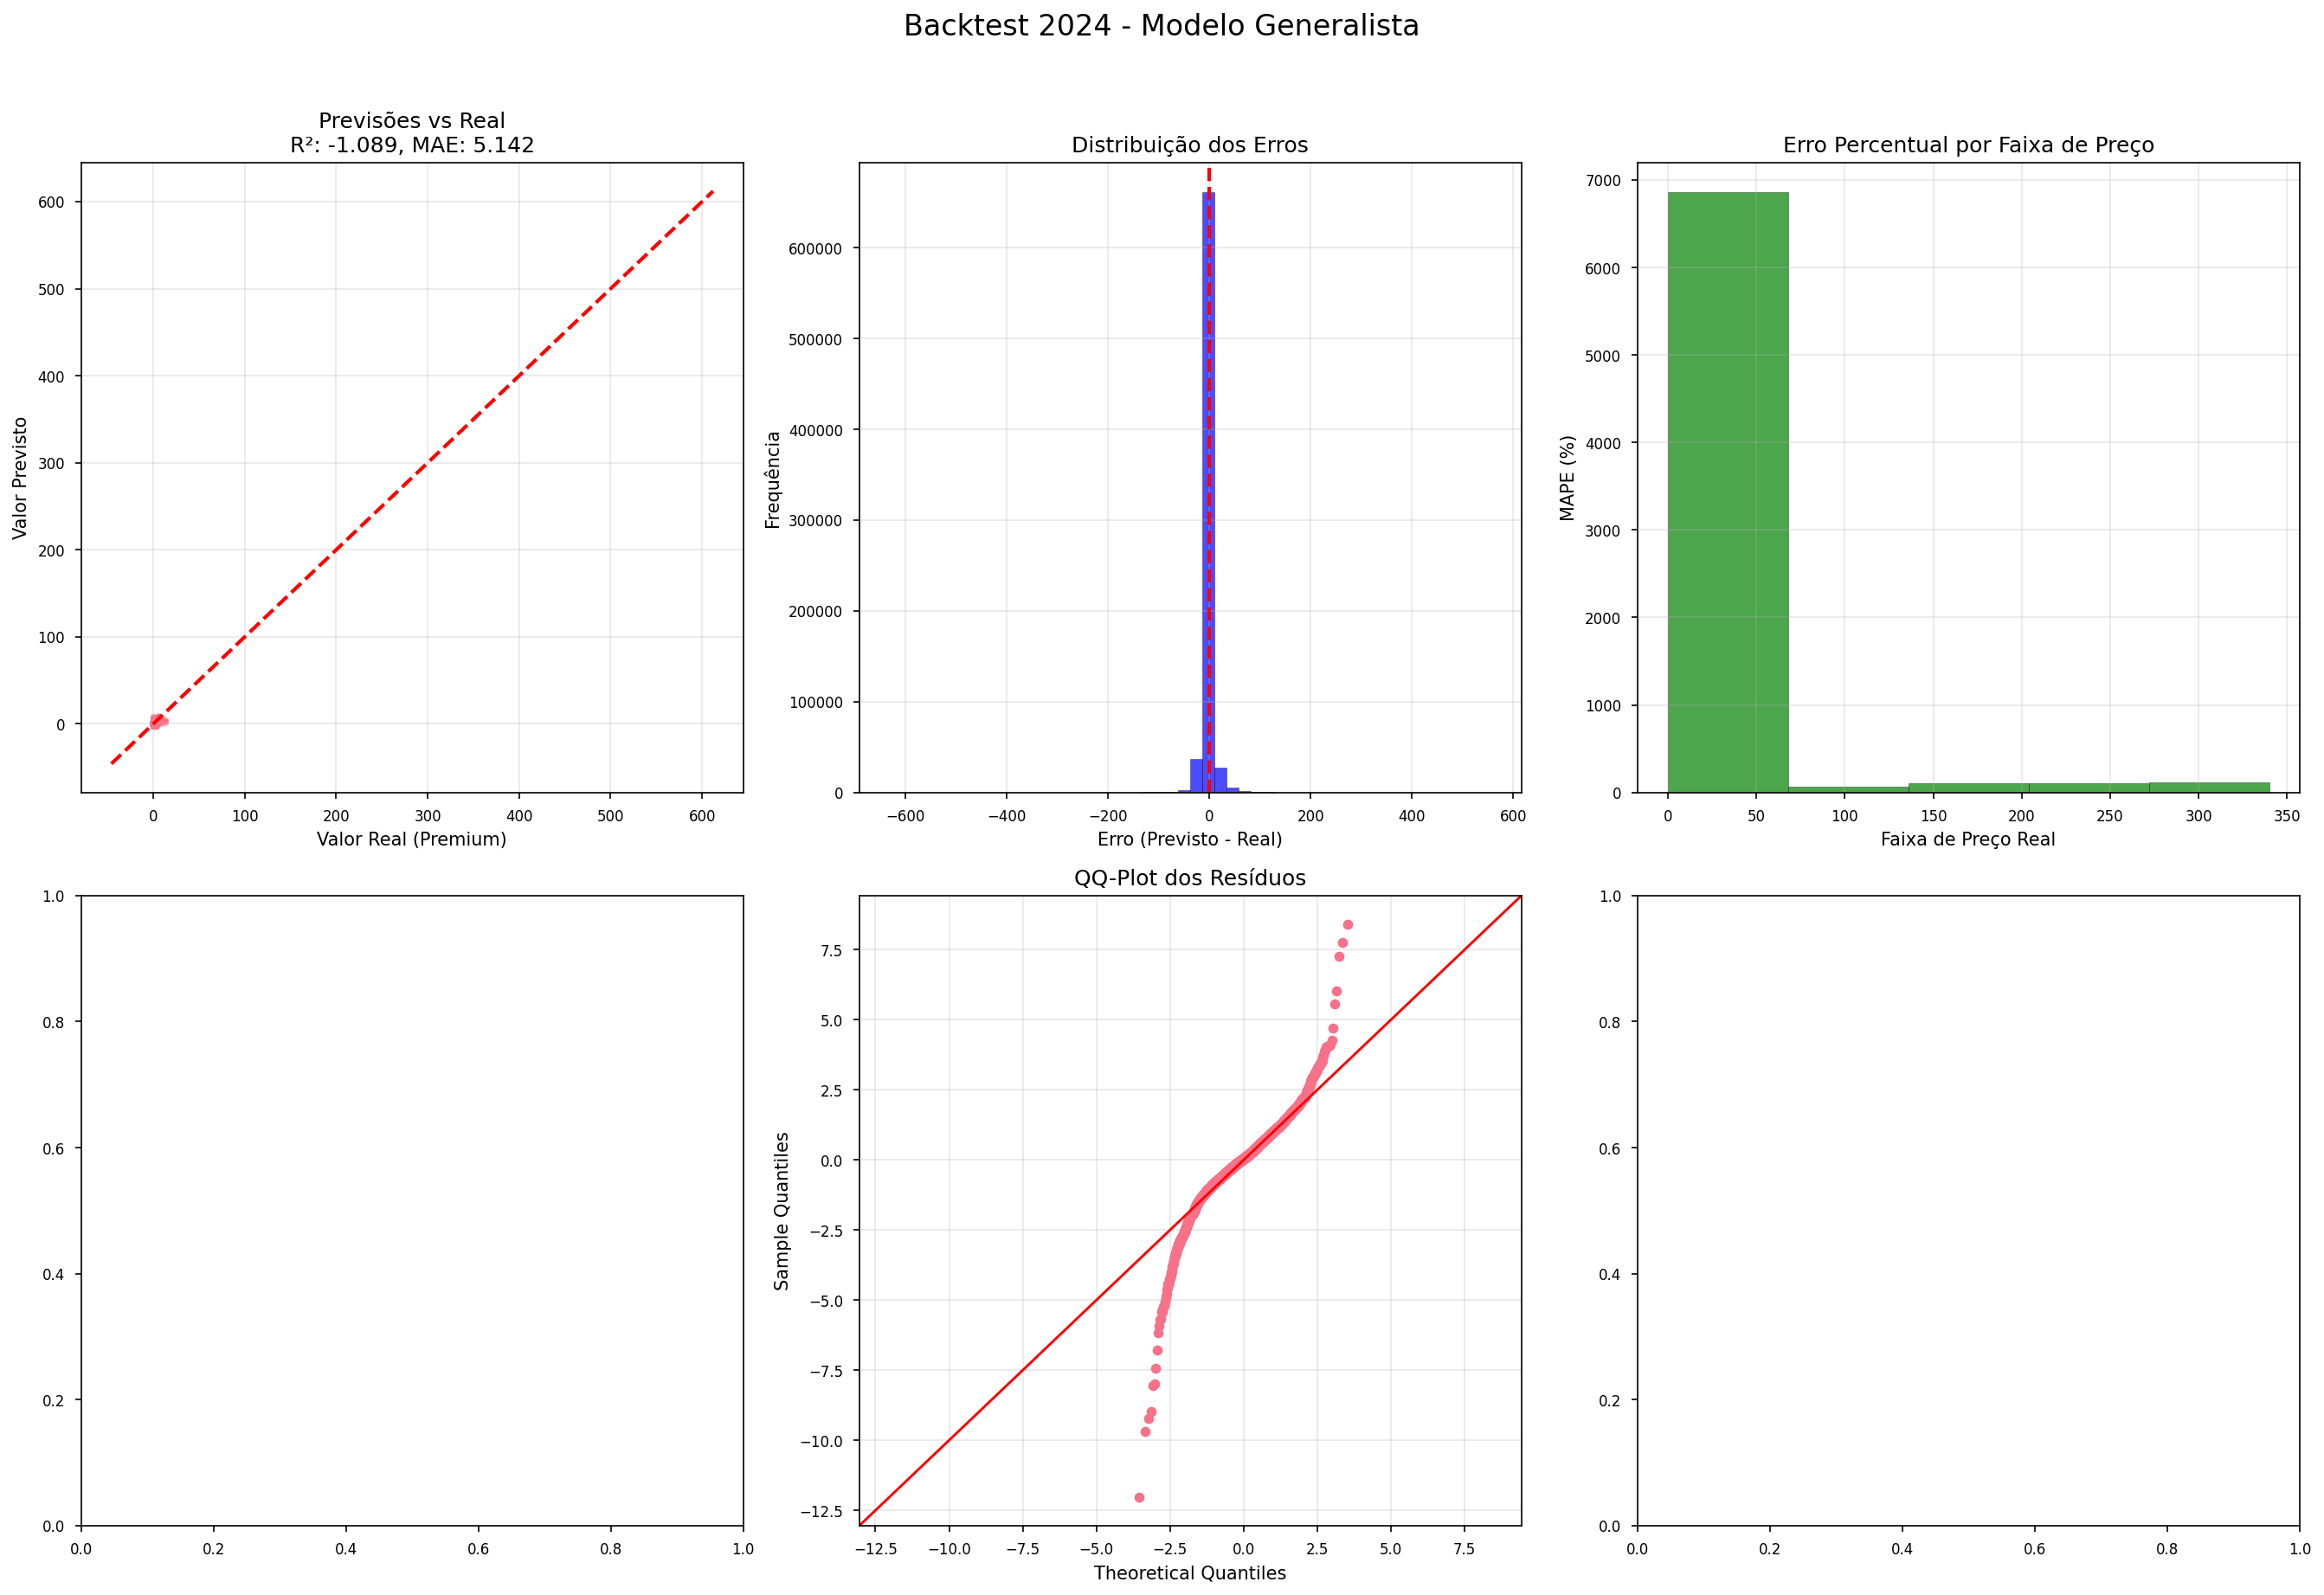

In [ ]:
#  8: Carregamento e Avaliação do Modelo Generalista

print("\n" + "="*70)
print("PARTE 2: AVALIAÇÃO DO MODELO GENERALISTA EM 2024")
print("="*70)

# Criar dataloader para 2024
val_loader_2024 = DataLoader(ds_2024, batch_size=512, shuffle=False)
model = load_adaptive_model(
    DeepHestonHybrid, 
    MODEL_CONFIG, 
    data_stats, 
    weights_path, 
    device
)
model_generalista = model.eval()

# Avaliar modelo
results_2024 = avaliar_modelo(model_generalista, val_loader_2024, data_stats, device, "Generalista (2024)")

# Plotar backtest detalhado
plot_backtest_2024(results_2024)

# Adicionar timestamps aos resultados para análise temporal
results_2024['timestamps'] = []
for batch in val_loader_2024:
    results_2024['timestamps'].extend(batch[3].numpy().flatten())
results_2024['timestamps'] = np.array(results_2024['timestamps'])


ANÁLISE POR ATIVO EM 2024

Métricas por Ativo (2024):
Ativo  Amostras       MAE      RMSE        R2         MAPE
 ABEV     25149  0.989341  1.474622 -0.003793  2049.921875
 B3SA     34244  1.086203  1.574669 -0.068341  1960.677734
 BBAS     60813  2.221513  3.627001  0.052532  2762.104004
 BBDC     49828  1.270546  2.446522  0.045654  2000.191284
 BOVA     98701 14.941772 21.698734 -3.184517 24939.568359
 CSNA     19609  1.272423  2.166049 -0.139140  1642.541138
 GGBR     26916  1.327826  1.902962 -0.741967  1654.805420
 ITUB     48176  2.198044  3.160377 -0.436562  2604.706055
 LREN     23311  1.718895  3.257185 -0.153603  1799.781006
 MGLU     58275  4.269645 16.507228 -0.218965  2246.123047
 PETR    139892  4.499854  6.910488 -0.280652  6650.242676
 SUZB     28716  4.442163  6.284797 -3.171728  3507.148438
 VALE     96612  7.713205 16.383824 -0.966973  7438.716797
 WEGE     26209  3.575717  4.826279 -0.382712  2598.613281


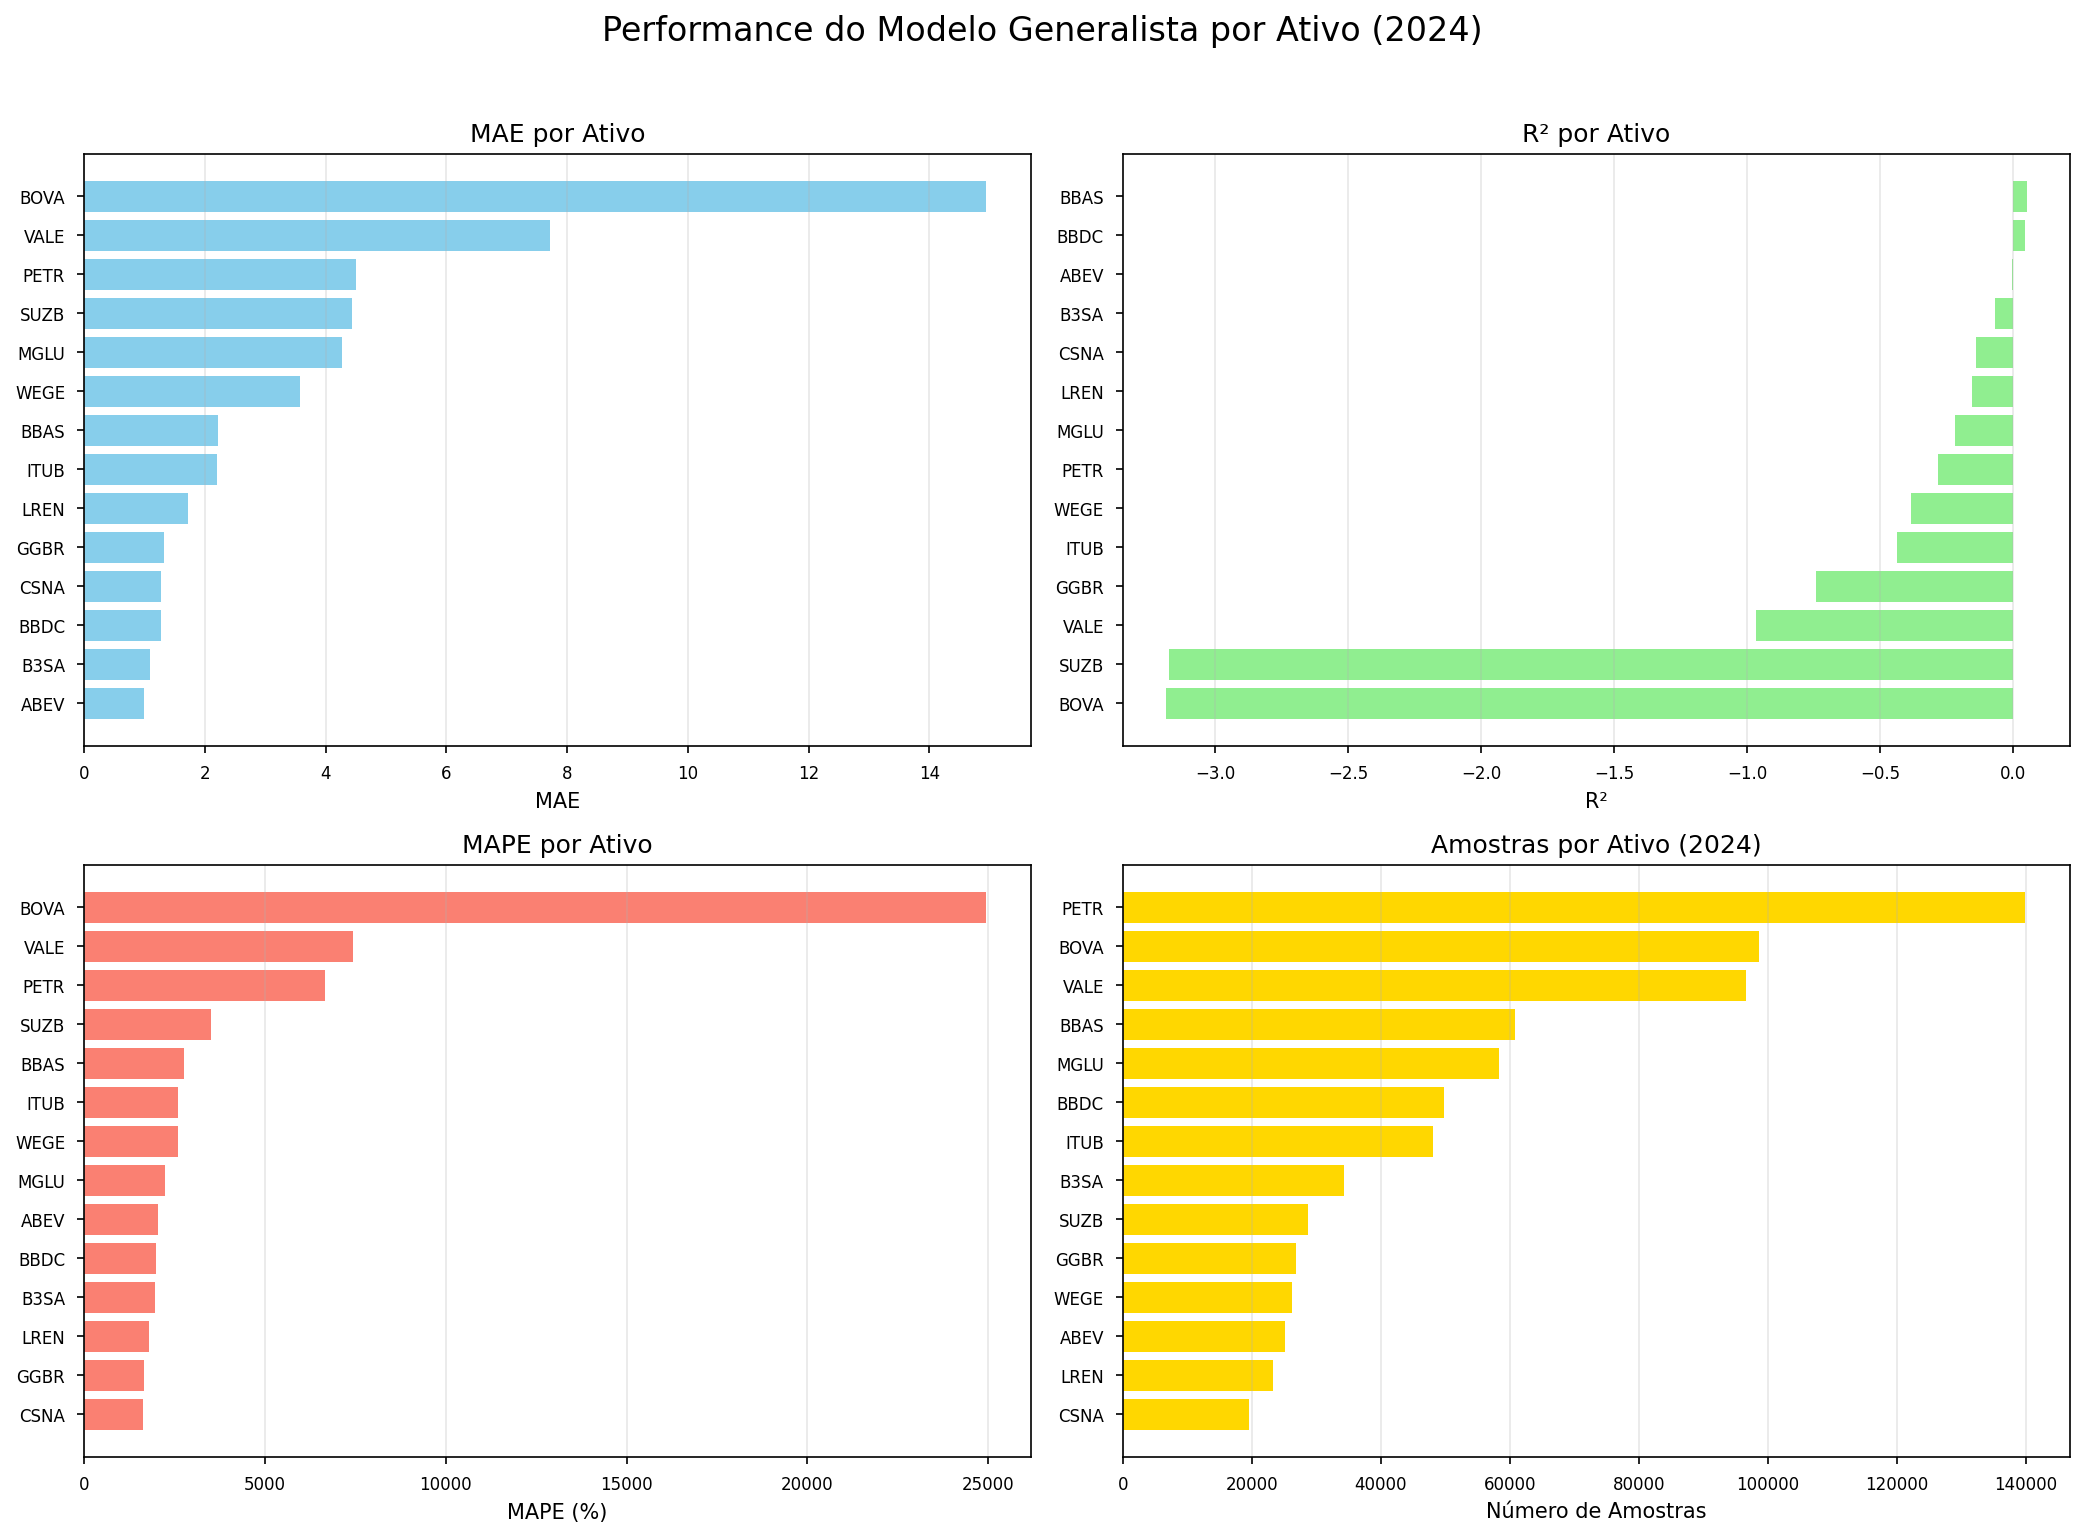

In [ ]:
#  Análise Detalhada por Ativo (2024)

def analyze_by_asset_2024(model, dataset_2024, data_stats, device):
    """
    Analisa performance por ativo em 2024.
    """
    model.eval()
    asset_map = data_stats['asset_map']
    asset_metrics = {}
    
    for asset_name, asset_id in asset_map.items():
        # Filtrar dataset por ativo
        asset_indices = []
        for i, (_, _, _, _, _, ids) in enumerate(dataset_2024):
            if ids.item() == asset_id:
                asset_indices.append(i)
        
        if not asset_indices:
            continue
        
        # Criar dataloader para o ativo
        asset_dataset = Subset(dataset_2024, asset_indices)
        asset_loader = DataLoader(asset_dataset, batch_size=256, shuffle=False)
        
        # Avaliar
        with torch.no_grad():
            all_preds = []
            all_targets = []
            
            for batch in asset_loader:
                x_seq, x_phy, y_norm, _, _, _ = [b.to(device) for b in batch]
                outputs = model(x_seq, x_phy, batch[5].to(device))
                
                # Desnormalizar
                K_real = x_phy[:, 1:2] * data_stats['K_std'] + data_stats['K_mean']
                price_pred = outputs['price'] * K_real
                price_real = y_norm * K_real
                
                all_preds.extend(price_pred.cpu().numpy().flatten())
                all_targets.extend(price_real.cpu().numpy().flatten())
        
        if len(all_targets) > 10:  # Mínimo de amostras
            metrics = calcular_metricas(np.array(all_targets), np.array(all_preds))
            asset_metrics[asset_name] = {
                'n_samples': len(all_targets),
                'metrics': metrics,
                'predictions': np.array(all_preds),
                'targets': np.array(all_targets)
            }
    
    return asset_metrics

# Executar análise por ativo
print("\n" + "="*70)
print("ANÁLISE POR ATIVO EM 2024")
print("="*70)

asset_results_2024 = analyze_by_asset_2024(model_generalista, ds_2024, data_stats, device)

# Criar dataframe com métricas por ativo
df_asset_metrics = pd.DataFrame({
    'Ativo': list(asset_results_2024.keys()),
    'Amostras': [asset_results_2024[a]['n_samples'] for a in asset_results_2024],
    'MAE': [asset_results_2024[a]['metrics']['MAE'] for a in asset_results_2024],
    'RMSE': [asset_results_2024[a]['metrics']['RMSE'] for a in asset_results_2024],
    'R2': [asset_results_2024[a]['metrics']['R2'] for a in asset_results_2024],
    'MAPE': [asset_results_2024[a]['metrics']['MAPE'] for a in asset_results_2024]
})

print("\nMétricas por Ativo (2024):")
print(df_asset_metrics.to_string(index=False))

# Plotar comparação de performance por ativo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MAE por ativo
df_mae = df_asset_metrics.sort_values('MAE')
axes[0, 0].barh(range(len(df_mae)), df_mae['MAE'], color='skyblue')
axes[0, 0].set_yticks(range(len(df_mae)))
axes[0, 0].set_yticklabels(df_mae['Ativo'])
axes[0, 0].set_xlabel('MAE')
axes[0, 0].set_title('MAE por Ativo')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# R² por ativo
df_r2 = df_asset_metrics.sort_values('R2')
axes[0, 1].barh(range(len(df_r2)), df_r2['R2'], color='lightgreen')
axes[0, 1].set_yticks(range(len(df_r2)))
axes[0, 1].set_yticklabels(df_r2['Ativo'])
axes[0, 1].set_xlabel('R²')
axes[0, 1].set_title('R² por Ativo')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# MAPE por ativo
df_mape = df_asset_metrics.sort_values('MAPE')
axes[1, 0].barh(range(len(df_mape)), df_mape['MAPE'], color='salmon')
axes[1, 0].set_yticks(range(len(df_mape)))
axes[1, 0].set_yticklabels(df_mape['Ativo'])
axes[1, 0].set_xlabel('MAPE (%)')
axes[1, 0].set_title('MAPE por Ativo')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Amostras por ativo
df_samples = df_asset_metrics.sort_values('Amostras')
axes[1, 1].barh(range(len(df_samples)), df_samples['Amostras'], color='gold')
axes[1, 1].set_yticks(range(len(df_samples)))
axes[1, 1].set_yticklabels(df_samples['Ativo'])
axes[1, 1].set_xlabel('Número de Amostras')
axes[1, 1].set_title('Amostras por Ativo (2024)')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Performance do Modelo Generalista por Ativo (2024)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['model_save_dir'], 'performance_por_ativo_2024.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  9: Visualizações do Modelo Generalista

print("\n" + "="*70)
print("VISUALIZAÇÕES DO MODELO GENERALISTA")
print("="*70)

# Instanciar visualizador
try:
    # Criar visualizador
    viz_gen = Visualizer(model_generalista, 
                        os.path.join(PATHS['model_save_dir'], 'training_history.csv'),
                        val_loader_2024,
                        data_stats,
                        VIZ_CONFIG)
    
    # Gerar plots (usar plot_all que já inclui vários plots)
    viz_gen.plot_all()
    
    # Plot específico de distribuição de erros (usando função separada)
    def plot_error_distribution(results_dict, title="Distribuição de Erros por Modelo"):
 
        fig, axes = plt.subplots(1, len(results_dict), figsize=(6*len(results_dict), 5))
    
    if len(results_dict) == 1:
        axes = [axes]
    
    for idx, (model_name, results) in enumerate(results_dict.items()):
        predictions = results['predictions']
        targets = results['targets']
        errors = predictions - targets
        
        axes[idx].hist(errors, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
        axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
        axes[idx].axvline(x=np.mean(errors), color='green', linestyle='--', 
                         linewidth=2, label=f'Média: {np.mean(errors):.4f}')
        axes[idx].set_xlabel('Erro (Previsto - Real)')
        axes[idx].set_ylabel('Frequência')
        axes[idx].set_title(f'{model_name}\nstd: {np.std(errors):.4f}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PATHS['model_save_dir'], 'error_distribution.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    plot_error_distribution({'Generalista': results_2024})
    
    print("Visualizações geradas com sucesso!")
except Exception as e:
    print(f"Erro durante visualizações: {e}")
    import traceback
    traceback.print_exc()



VISUALIZAÇÕES DO MODELO GENERALISTA
[INFO] Iniciando geração de gráficos em: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\plots
[WARNING] Arquivo de histórico não encontrado.
[INFO] Executando inferência completa no dataset de validação...
[INFO] Distribuição de erros plotada. Média=-0.0160, Std=0.6532
[INFO] Rotina de visualização finalizada.
Erro durante visualizações: name 'results_dict' is not defined


Traceback (most recent call last):
  File "C:\Users\Rubens Molina\AppData\Local\Temp\ipykernel_92168\3795576263.py", line 24, in <module>
    if len(results_dict) == 1:
           ^^^^^^^^^^^^
NameError: name 'results_dict' is not defined. Did you mean: 'results_2024'?


## 3. Análise do Modelo Refinado (Especialista)

In [ ]:
#  10: Início da Parte 2 - Análise dos Modelos Especializados

print("PARTE 3: ANÁLISE DOS MODELOS ESPECIALIZADOS POR ATIVO")


# Lista de ativos para análise
ativos = ['CSNA', 'WEGE', 'ABEV', 'VALE', 'BBAS', 'LREN', 'B3SA', 
          'PETR', 'ITUB', 'MGLU', 'GGBR', 'BBDC', 'SUZB', 'BOVA']

print(f"\nAtivos a serem analisados: {len(ativos)}")
print(", ".join(ativos))

# Dicionário para armazenar resultados
resultados_comparativos = {
    'Generalista': results_2024  
}
resultados_especialistas = {}

PARTE 3: ANÁLISE DOS MODELOS ESPECIALIZADOS POR ATIVO

Ativos a serem analisados: 14
CSNA, WEGE, ABEV, VALE, BBAS, LREN, B3SA, PETR, ITUB, MGLU, GGBR, BBDC, SUZB, BOVA


In [ ]:
# Adicione esta função após a função plot_backtest_2024 existente

def plot_asset_specialist_backtest(models_dict, ds_2024, data_stats, device, 
                                  asset_names, start_date="2024-01-01", end_date="2024-12-31"):
    """
    Plota backtest estilo mercado financeiro para modelos especialistas por ativo.
    
    Args:
        models_dict: Dicionário {nome_ativo: modelo_especialista}
        ds_2024: Dataset completo de 2024
        data_stats: Estatísticas de normalização
        device: Dispositivo (CPU/GPU)
        asset_names: Lista de ativos a analisar
        start_date: Data inicial do período
        end_date: Data final do período
    """
    
    import pandas as pd
    import matplotlib.pyplot as plt
    from datetime import datetime
    import numpy as np
    
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.rcParams['figure.figsize'] = (16, 10)
    plt.rcParams['figure.dpi'] = 120
    plt.rcParams['font.size'] = 11
    
    fig, axes = plt.subplots(len(asset_names), 2, figsize=(18, 5*len(asset_names)))
    if len(asset_names) == 1:
        axes = axes.reshape(1, 2)
    
    # Converter dataset para DataFrame para facilitar filtragem por ativo
    all_predictions = []
    all_targets = []
    all_timestamps = []
    all_assets = []
    all_model_types = []
    
    # Primeiro: Coletar dados do modelo generalista (se disponível)
    print("Coletando previsões dos modelos...")
    
    for asset_idx, asset_name in enumerate(asset_names):
        print(f"  Processando {asset_name}...")
        
        # Filtrar dados apenas para este ativo
        asset_id = data_stats['asset_map'][asset_name]
        asset_indices = []
        
        # Encontrar índices deste ativo no dataset
        for i, (_, _, _, _, _, ids) in enumerate(DataLoader(ds_2024, batch_size=1)):
            if ids.item() == asset_id:
                asset_indices.append(i)
        
        if not asset_indices:
            print(f"    Nenhum dado encontrado para {asset_name} em 2024")
            continue
        
        # Criar DataLoader apenas para este ativo
        from torch.utils.data import Subset
        ds_asset = Subset(ds_2024, asset_indices)
        loader_asset = DataLoader(ds_asset, batch_size=256, shuffle=False)
        
        # Avaliar modelo especialista (se disponível)
        if asset_name in models_dict:
            model = models_dict[asset_name]
            model.eval()
            
            asset_predictions = []
            asset_targets = []
            asset_timestamps = []
            
            with torch.no_grad():
                for batch in loader_asset:
                    x_seq, x_phy, y_norm, timestamps, _, ids = [b.to(device) for b in batch]
                    
                    outputs = model(x_seq, x_phy, ids)
                    
                    # Desnormalizar preços
                    K_real = x_phy[:, 1:2] * data_stats['K_std'] + data_stats['K_mean']
                    price_pred = outputs['price'] * K_real
                    price_real = y_norm * K_real
                    
                    asset_predictions.extend(price_pred.cpu().numpy().flatten())
                    asset_targets.extend(price_real.cpu().numpy().flatten())
                    asset_timestamps.extend(timestamps.cpu().numpy().flatten())
            
            # Adicionar ao DataFrame geral
            for i in range(len(asset_predictions)):
                all_predictions.append(asset_predictions[i])
                all_targets.append(asset_targets[i])
                all_timestamps.append(asset_timestamps[i])
                all_assets.append(asset_name)
                all_model_types.append('Especialista')
    
    # Criar DataFrame com todos os dados
    df_results = pd.DataFrame({
        'timestamp': all_timestamps,
        'ativo': all_assets,
        'modelo': all_model_types,
        'preco_real': all_targets,
        'preco_previsto': all_predictions
    })
    
    df_results['data'] = pd.to_datetime(df_results['timestamp'], unit='s')
    df_results = df_results[(df_results['data'] >= start_date) & 
                           (df_results['data'] <= end_date)]
    
    if df_results.empty:
        print("Nenhum dado encontrado para o período especificado.")
        return
    
    # Plot para cada ativo
    for asset_idx, asset_name in enumerate(asset_names):
        df_asset = df_results[df_results['ativo'] == asset_name]
        
        if df_asset.empty:
            axes[asset_idx, 0].text(0.5, 0.5, f'Dados insuficientes\npara {asset_name}',
                                  horizontalalignment='center', verticalalignment='center',
                                  transform=axes[asset_idx, 0].transAxes, fontsize=12)
            axes[asset_idx, 0].set_title(f'{asset_name} - Evolução Temporal', fontsize=14)
            axes[asset_idx, 0].grid(False)
            axes[asset_idx, 1].grid(False)
            continue
        
        # Agrupar por dia (média diária)
        df_daily = df_asset.groupby(pd.Grouper(key='data', freq='D')).agg({
            'preco_real': 'mean',
            'preco_previsto': 'mean'
        }).reset_index()
        
        df_daily = df_daily.dropna()
        
        if len(df_daily) < 2:
            continue
        
        # --- Gráfico 1: Evolução Temporal (Estilo Mercado Financeiro) ---
        ax1 = axes[asset_idx, 0]
        
        # Plotar área entre as curvas
        ax1.fill_between(df_daily['data'], df_daily['preco_previsto'], 
                        df_daily['preco_real'], 
                        alpha=0.2, color='red', label='Diferença')
        
        # Plotar linhas principais
        line_real, = ax1.plot(df_daily['data'], df_daily['preco_real'], 
                             linewidth=2, color='green', alpha=0.8, label='Real')
        line_pred, = ax1.plot(df_daily['data'], df_daily['preco_previsto'], 
                             linewidth=2, color='blue', alpha=0.8, label='Previsto (Especialista)')
        
        # Adicionar média móvel
        window = min(5, len(df_daily))
        if window > 1:
            df_daily['real_sma'] = df_daily['preco_real'].rolling(window=window).mean()
            df_daily['pred_sma'] = df_daily['preco_previsto'].rolling(window=window).mean()
            
            ax1.plot(df_daily['data'], df_daily['real_sma'], '--', 
                    color='darkgreen', linewidth=1.5, alpha=0.6, label=f'Real (MM{window})')
            ax1.plot(df_daily['data'], df_daily['pred_sma'], '--', 
                    color='darkblue', linewidth=1.5, alpha=0.6, label=f'Previsto (MM{window})')
        
        # Formatação do gráfico
        ax1.set_title(f'{asset_name} - Evolução Temporal (2024)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Data', fontsize=12)
        ax1.set_ylabel('Preço Premium (R$)', fontsize=12)
        ax1.legend(loc='upper left', fontsize=10)
        ax1.grid(True, alpha=0.3)
        
        # Formatar eixo X com datas
        ax1.xaxis.set_major_locator(plt.MaxNLocator(6))
        ax1.tick_params(axis='x', rotation=45)
        
        # --- Gráfico 2: Erro Absoluto Percentual ao Longo do Tempo ---
        ax2 = axes[asset_idx, 1]
        
        # Calcular erro percentual
        df_daily['erro_percentual'] = (abs(df_daily['preco_previsto'] - df_daily['preco_real']) / 
                                      df_daily['preco_real']) * 100
        
        # Plotar erro como área
        ax2.fill_between(df_daily['data'], 0, df_daily['erro_percentual'],
                        alpha=0.3, color='orange', label='Erro %')
        
        # Linha de erro
        ax2.plot(df_daily['data'], df_daily['erro_percentual'],
                linewidth=2, color='red', alpha=0.7)
        
        # Linha da média
        mean_error = df_daily['erro_percentual'].mean()
        ax2.axhline(y=mean_error, color='darkred', linestyle='--', 
                   linewidth=1.5, alpha=0.7, label=f'Média: {mean_error:.2f}%')
        
        # Formatação
        ax2.set_title(f'{asset_name} - Erro Percentual (2024)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Data', fontsize=12)
        ax2.set_ylabel('Erro Absoluto Percentual (%)', fontsize=12)
        ax2.legend(loc='upper left', fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.xaxis.set_major_locator(plt.MaxNLocator(6))
        ax2.tick_params(axis='x', rotation=45)
        
        # Adicionar estatísticas na legenda
        stats_text = (f'MAE: {np.mean(np.abs(df_daily["preco_previsto"] - df_daily["preco_real"])):.4f}\n'
                     f'RMSE: {np.sqrt(np.mean((df_daily["preco_previsto"] - df_daily["preco_real"])**2)):.4f}\n'
                     f'R²: {np.corrcoef(df_daily["preco_previsto"], df_daily["preco_real"])[0,1]**2:.4f}')
        
        ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    
    # Salvar gráfico
    save_path = os.path.join(PATHS['model_save_dir'], 'backtest_especialistas_2024.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Gráfico salvo em: {save_path}")
    
    # Retornar DataFrame com resultados para análise adicional
    return df_results

In [ ]:
def compare_generalist_vs_specialists(generalist_model, specialists_dict, ds_2024, 
                                      data_stats, device, asset_names):
    """
    Compara detalhadamente o modelo generalista vs modelos especialistas.
    Gera múltiplas visualizações e métricas comparativas.
    """
    
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    from datetime import datetime
    from torch.utils.data import DataLoader, Subset
    
    # Configurações de plotagem
    plt.style.use('seaborn-v0_8-darkgrid')
    
    # Coletar dados de todos os modelos
    all_results = []
    
    for asset_name in asset_names:
        print(f"\nProcessando {asset_name}...")
        
        # Filtrar dados do ativo
        asset_id = data_stats['asset_map'][asset_name]
        asset_indices = []
        
        for i, (_, _, _, _, _, ids) in enumerate(DataLoader(ds_2024, batch_size=1)):
            if ids.item() == asset_id:
                asset_indices.append(i)
        
        if not asset_indices:
            print(f"  Nenhum dado encontrado para {asset_name}")
            continue
        
        ds_asset = Subset(ds_2024, asset_indices)
        loader_asset = DataLoader(ds_asset, batch_size=256, shuffle=False)
        
        # Testar modelos
        for model_name, model in [('Generalista', generalist_model)] + \
                                [(f'Especialista_{asset}', mod) for asset, mod in specialists_dict.items() 
                                 if asset == asset_name]:
            
            if model is None:
                continue
                
            model.eval()
            predictions = []
            targets = []
            timestamps = []
            
            with torch.no_grad():
                for batch in loader_asset:
                    x_seq, x_phy, y_norm, ts, _, ids = [b.to(device) for b in batch]
                    
                    outputs = model(x_seq, x_phy, ids)
                    
                    # Desnormalizar
                    K_real = x_phy[:, 1:2] * data_stats['K_std'] + data_stats['K_mean']
                    price_pred = outputs['price'] * K_real
                    price_real = y_norm * K_real
                    
                    predictions.extend(price_pred.cpu().numpy().flatten())
                    targets.extend(price_real.cpu().numpy().flatten())
                    timestamps.extend(ts.cpu().numpy().flatten())
            
            # Calcular métricas
            mae = np.mean(np.abs(np.array(predictions) - np.array(targets)))
            rmse = np.sqrt(np.mean((np.array(predictions) - np.array(targets))**2))
            mape = np.mean(np.abs(np.array(predictions) - np.array(targets)) / 
                          (np.abs(np.array(targets)) + 1e-8)) * 100
            r2 = np.corrcoef(predictions, targets)[0,1]**2 if len(predictions) > 1 else 0
            
            all_results.append({
                'ativo': asset_name,
                'modelo': model_name,
                'mae': mae,
                'rmse': rmse,
                'mape': mape,
                'r2': r2,
                'n_amostras': len(predictions)
            })
    
    # Criar DataFrame comparativo
    df_comparison = pd.DataFrame(all_results)
    
    if df_comparison.empty:
        print("Nenhum resultado encontrado.")
        return None
    
    # --- Gráfico 1: Comparação de Métricas por Ativo ---
    fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
    axes1 = axes1.flatten()
    
    metrics = ['mae', 'rmse', 'mape', 'r2']
    metric_names = ['MAE (R$)', 'RMSE (R$)', 'MAPE (%)', 'R²']
    
    for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
        ax = axes1[idx]
        
        # Criar pivot table
        pivot_df = df_comparison.pivot(index='ativo', columns='modelo', values=metric)
        
        # Plotar barras agrupadas
        width = 0.35
        x = np.arange(len(pivot_df.index))
        
        models_in_data = pivot_df.columns.tolist()
        for i, model in enumerate(models_in_data):
            offset = width * (i - len(models_in_data)/2 + 0.5)
            bars = ax.bar(x + offset, pivot_df[model].values, width, 
                         label=model, alpha=0.8)
            
            # Adicionar valores nas barras
            for bar, val in zip(bars, pivot_df[model].values):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01*height,
                       f'{val:.4f}', ha='center', va='bottom', fontsize=8)
        
        ax.set_xlabel('Ativo', fontsize=12)
        ax.set_ylabel(metric_name, fontsize=12)
        ax.set_title(f'Comparação de {metric_name} por Modelo', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(pivot_df.index, rotation=45)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PATHS['model_save_dir'], 'comparacao_metricas_geral.png'), 
                dpi=150, bbox_inches='tight')
    
    # --- Gráfico 2: Heatmap de Melhoria ---
    fig2, ax2 = plt.subplots(figsize=(14, 8))
    
    # Calcular melhoria do especialista em relação ao generalista
    improvement_data = []
    
    for asset in df_comparison['ativo'].unique():
        generalista_data = df_comparison[(df_comparison['ativo'] == asset) & 
                                        (df_comparison['modelo'] == 'Generalista')]
        especialista_data = df_comparison[(df_comparison['ativo'] == asset) & 
                                         (df_comparison['modelo'].str.contains('Especialista'))]
        
        if not generalista_data.empty and not especialista_data.empty:
            gen_mape = generalista_data['mape'].values[0]
            esp_mape = especialista_data['mape'].values[0]
            melhoria = ((gen_mape - esp_mape) / gen_mape) * 100
            
            improvement_data.append({
                'ativo': asset,
                'mape_generalista': gen_mape,
                'mape_especialista': esp_mape,
                'melhoria_%': melhoria
            })
    
    df_improvement = pd.DataFrame(improvement_data)
    
    if not df_improvement.empty:
        # Ordenar por melhoria
        df_improvement = df_improvement.sort_values('melhoria_%', ascending=False)
        
        # Plotar gráfico de barras duplas
        x = np.arange(len(df_improvement))
        width = 0.35
        
        bars1 = ax2.bar(x - width/2, df_improvement['mape_generalista'], 
                       width, label='Generalista', color='skyblue', alpha=0.8)
        bars2 = ax2.bar(x + width/2, df_improvement['mape_especialista'], 
                       width, label='Especialista', color='lightcoral', alpha=0.8)
        
        # Adicionar porcentagem de melhoria acima das barras
        for i, (_, row) in enumerate(df_improvement.iterrows()):
            ax2.text(i, max(row['mape_generalista'], row['mape_especialista']) + 1,
                    f"{row['melhoria_%']:.1f}%", ha='center', va='bottom', fontsize=10)
        
        ax2.set_xlabel('Ativo', fontsize=12)
        ax2.set_ylabel('MAPE (%)', fontsize=12)
        ax2.set_title('Melhoria do Especialista vs Generalista (MAPE)', 
                     fontsize=14, fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(df_improvement['ativo'], rotation=45)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Adicionar linha de média
        avg_improvement = df_improvement['melhoria_%'].mean()
        ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
        ax2.text(len(df_improvement)-1, 0.5, f'Média: {avg_improvement:.1f}%',
                ha='right', va='bottom', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    plt.savefig(os.path.join(PATHS['model_save_dir'], 'melhoria_especialistas.png'), 
                dpi=150, bbox_inches='tight')
    
    # --- Salvar resultados em CSV ---
    df_comparison.to_csv(os.path.join(PATHS['model_save_dir'], 
                                     'comparacao_completa_models.csv'), index=False)
    
    if not df_improvement.empty:
        df_improvement.to_csv(os.path.join(PATHS['model_save_dir'], 
                                          'melhoria_especialistas.csv'), index=False)
    
    plt.show()
    
    print("\n" + "="*60)
    print("ANÁLISE COMPARATIVA COMPLETA")
    print("="*60)
    
    # Estatísticas resumidas
    if not df_improvement.empty:
        print(f"\nMédia de melhoria dos especialistas: {df_improvement['melhoria_%'].mean():.2f}%")
        print(f"Melhor melhoria: {df_improvement['melhoria_%'].max():.2f}% ({df_improvement.iloc[0]['ativo']})")
        print(f"Pior melhoria: {df_improvement['melhoria_%'].min():.2f}% ({df_improvement.iloc[-1]['ativo']})")
    
    return df_comparison, df_improvement

In [ ]:
def run_complete_backtest_analysis():
    """
    Executa análise completa de backtest para todos os modelos.
    """
    
    print("="*80)
    print("ANÁLISE COMPLETA DE BACKTEST - MODELOS ESPECIALISTAS 2024")
    print("="*80)
    
    # 1. Carregar modelo generalista
    print("\n1. Carregando modelo generalista...")
    generalist_model = load_adaptive_model(
        DeepHestonHybrid, 
        MODEL_CONFIG, 
        data_stats, 
        os.path.join(PATHS['model_save_dir'], 'best_model_weights.pth'),
        device
    )
    
    # 2. Carregar modelos especialistas (assumindo que foram salvos em PATHS['specialists_dir'])
    print("\n2. Carregando modelos especialistas...")
    specialists_dir = os.path.join(PATHS['model_save_dir'], 'especialistas')
    specialists_dict = {}
    
    if os.path.exists(specialists_dir):
        for asset_name in data_stats['asset_map'].keys():
            model_path = os.path.join(specialists_dir, f'model_{asset_name}.pth')
            if os.path.exists(model_path):
                try:
                    specialist_model = load_adaptive_model(
                        DeepHestonHybrid,
                        MODEL_CONFIG,
                        data_stats,
                        model_path,
                        device
                    )
                    specialists_dict[asset_name] = specialist_model
                    print(f"  ✓ {asset_name}: Carregado com sucesso")
                except Exception as e:
                    print(f"  ✗ {asset_name}: Erro ao carregar - {e}")
    else:
        print("  Aviso: Pasta de especialistas não encontrada.")
        print("  Execute primeiro o fine-tuning para criar modelos especialistas.")
    
    # 3. Definir ativos para análise (todos ou selecionados)
    asset_names = list(data_stats['asset_map'].keys())[:6]  # Analisar apenas os 6 primeiros para exemplo
    print(f"\n3. Ativos selecionados para análise: {asset_names}")
    
    # 4. Executar backtest temporal por ativo
    print("\n4. Executando backtest temporal...")
    df_results = plot_asset_specialist_backtest(
        models_dict=specialists_dict,
        ds_2024=ds_2024,
        data_stats=data_stats,
        device=device,
        asset_names=asset_names,
        start_date="2024-01-01",
        end_date="2024-12-31"
    )
    
    # 5. Comparação detalhada generalista vs especialistas
    print("\n5. Realizando comparação detalhada...")
    if specialists_dict:
        df_comparison, df_improvement = compare_generalist_vs_specialists(
            generalist_model=generalist_model,
            specialists_dict=specialists_dict,
            ds_2024=ds_2024,
            data_stats=data_stats,
            device=device,
            asset_names=asset_names
        )
    else:
        print("  Pular comparação: Nenhum modelo especialista carregado.")
    
    print("\n" + "="*80)
    print("ANÁLISE DE BACKTEST CONCLUÍDA!")
    print("="*80)
    
    # Retornar resultados para análise adicional
    return {
        'generalist_model': generalist_model,
        'specialists_dict': specialists_dict,
        'df_results': df_results if 'df_results' in locals() else None,
        'df_comparison': df_comparison if 'df_comparison' in locals() else None,
        'df_improvement': df_improvement if 'df_improvement' in locals() else None
    }

ANÁLISE COMPLETA DE BACKTEST - MODELOS ESPECIALISTAS 2024

1. Carregando modelo generalista...
Carregando modelo de: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\modelo_final\best_model_weights.pth
Detectado LSTM input_size no checkpoint: 10
  -> Configurado sem embeddings (10 features diretas)
  -> Reconstruindo Pricing Net com 5 camadas...
Camadas inesperadas: ['asset_embedding.weight']

2. Carregando modelos especialistas...
  Aviso: Pasta de especialistas não encontrada.
  Execute primeiro o fine-tuning para criar modelos especialistas.

3. Ativos selecionados para análise: ['ABEV', 'B3SA', 'BBAS', 'BBDC', 'BOVA', 'CSNA']

4. Executando backtest temporal...
Coletando previsões dos modelos...
  Processando ABEV...
  Processando B3SA...
  Processando BBAS...
  Processando BBDC...
  Processando BOVA...
  Processando CSNA...
Nenhum dado encontrado para o período especificado.

5. Realizando comparação detalhada...
  Pular comparação: Nenhum modelo especialista carregado.

AN

NameError: name 'specialists_dict' is not defined

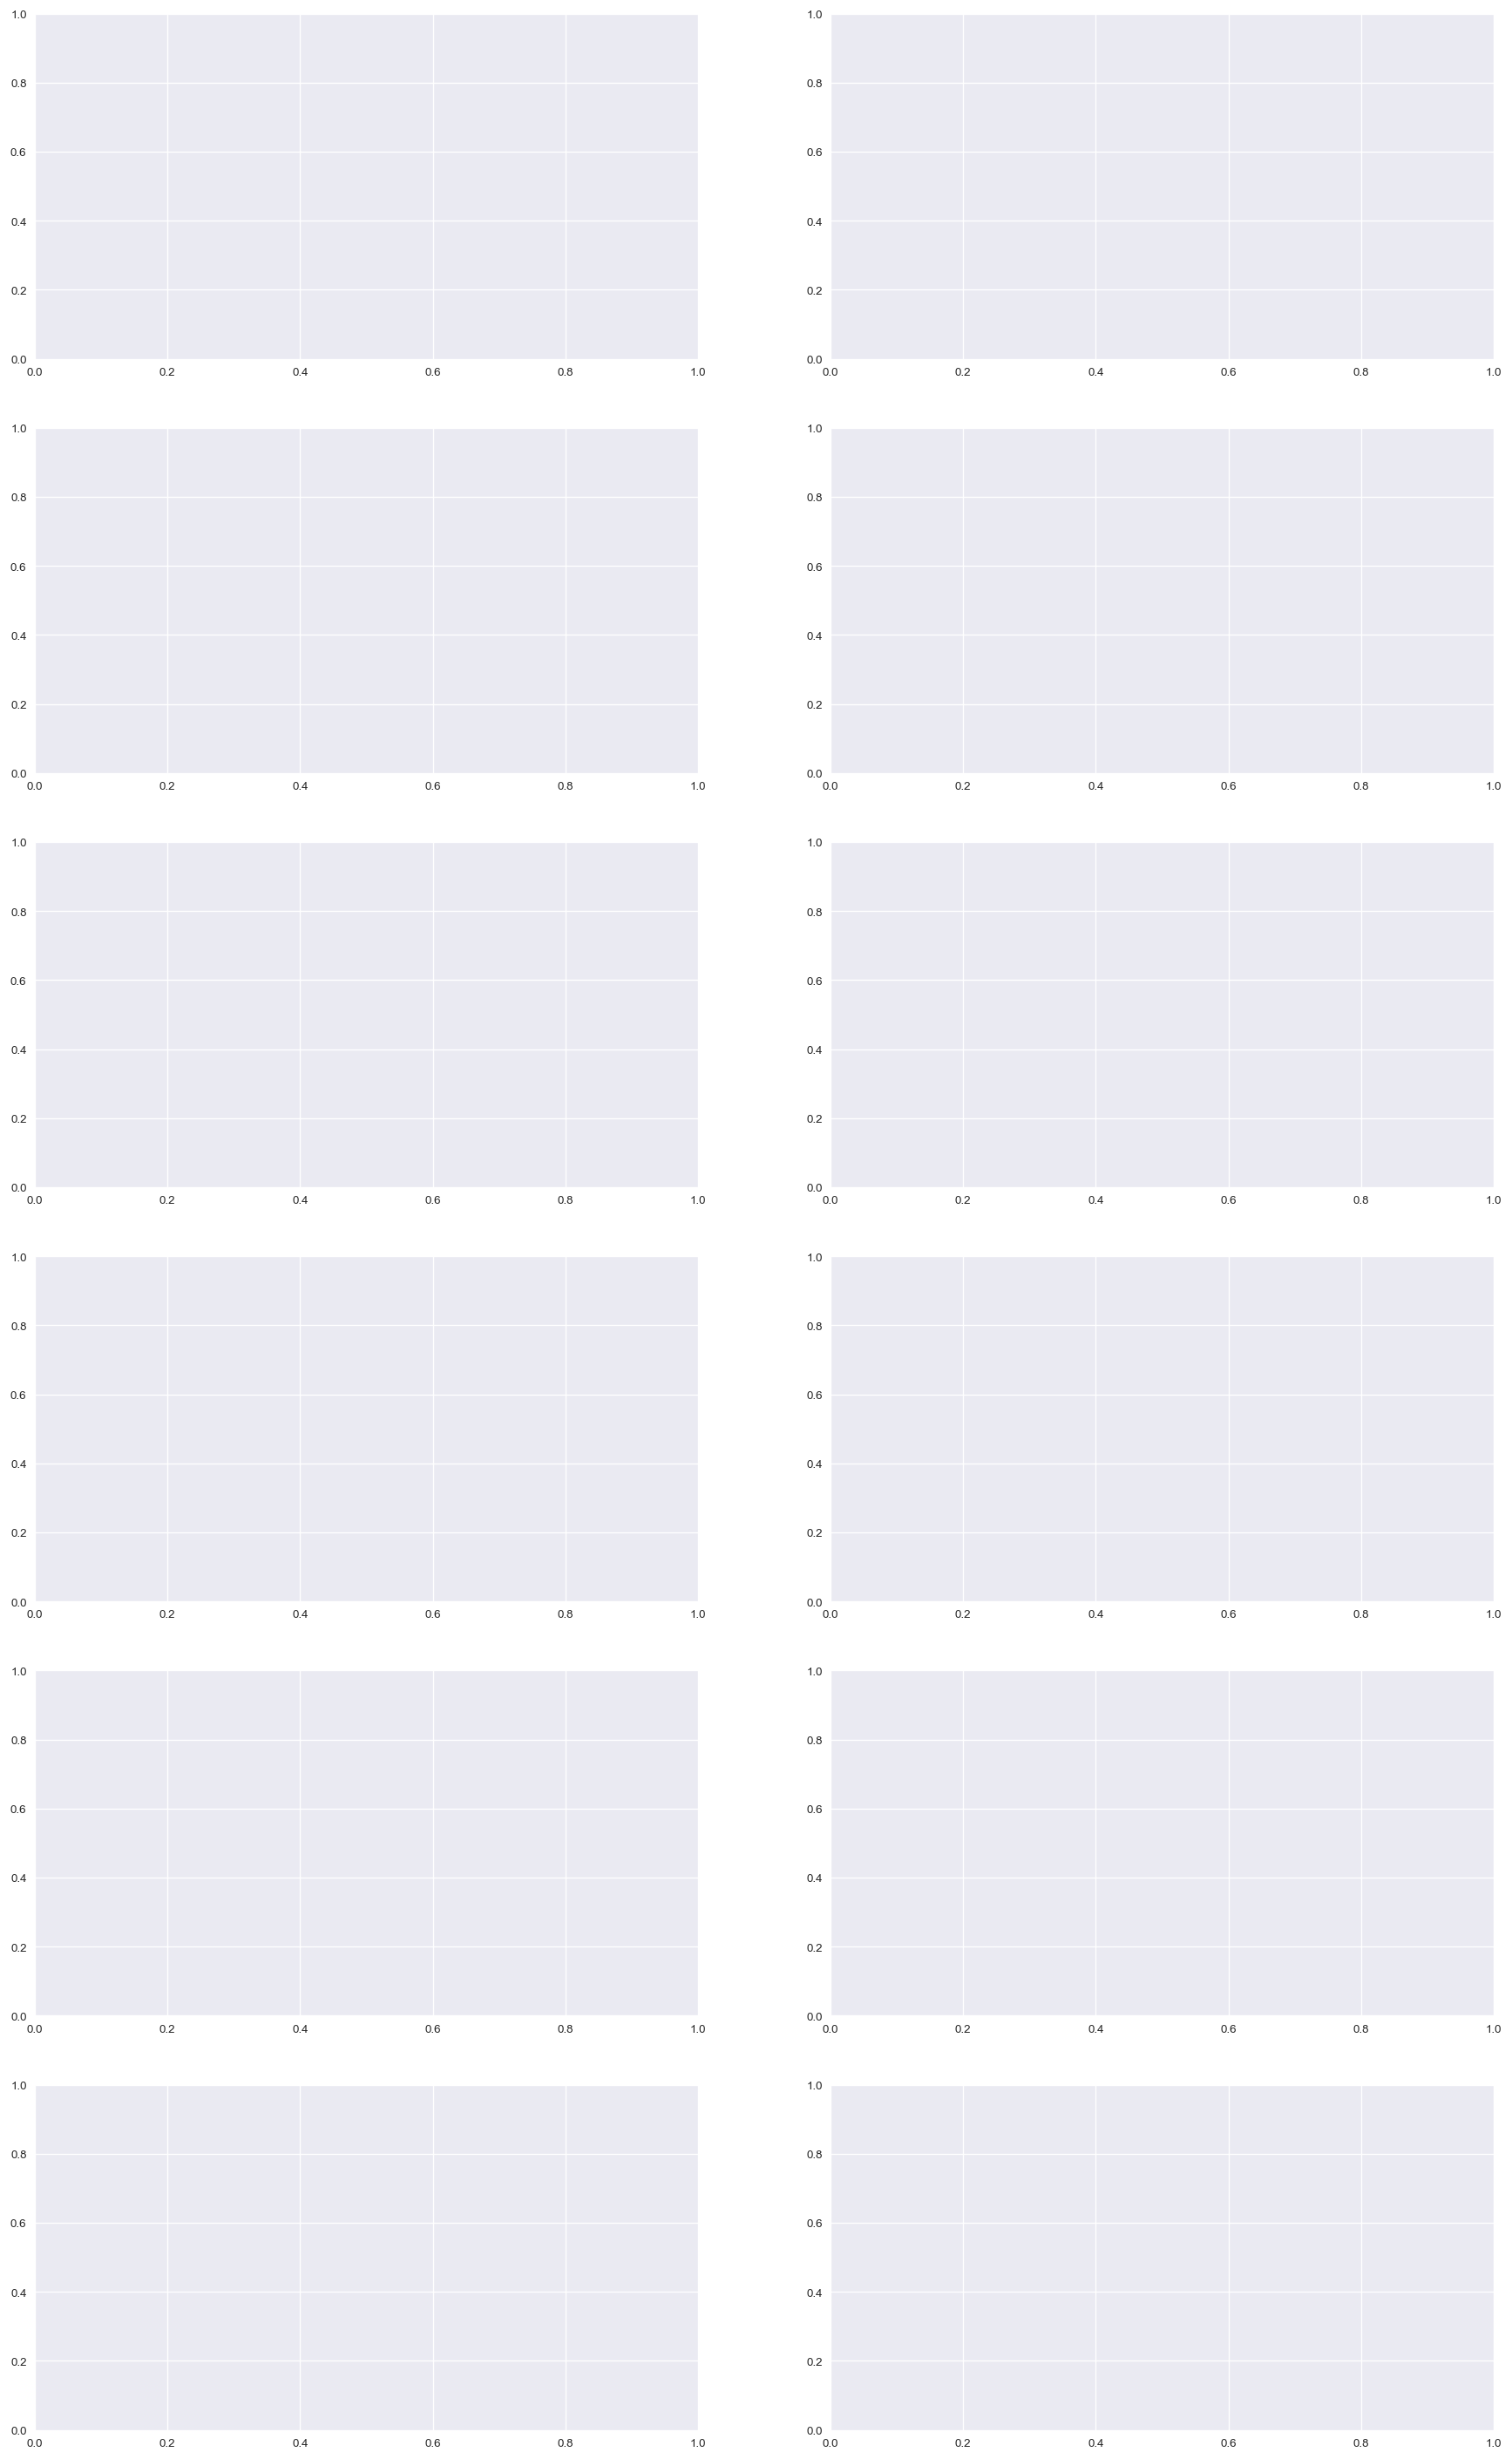

In [ ]:
# Execute a análise completa
resultados_backtest = run_complete_backtest_analysis()

# Ou execute partes específicas:

# Apenas o backtest temporal
df_backtest = plot_asset_specialist_backtest(
    models_dict=specialists_dict,
    ds_2024=ds_2024,
    data_stats=data_stats,
    device=device,
    asset_names=['PETR', 'VALE', 'ITUB'],  # Ativos específicos
    start_date="2024-01-01",
    end_date="2024-06-30"  # Primeiro semestre
)

# Apenar comparação
df_comp, df_imp = compare_generalist_vs_specialists(
    generalist_model=generalist_model,
    specialists_dict=specialists_dict,
    ds_2024=ds_2024,
    data_stats=data_stats,
    device=device,
    asset_names=['PETR', 'VALE', 'ITUB', 'BBAS', 'BOVA']
)


GERANDO CURVAS 3D DE BLACK-SCHOLES POR ATIVO


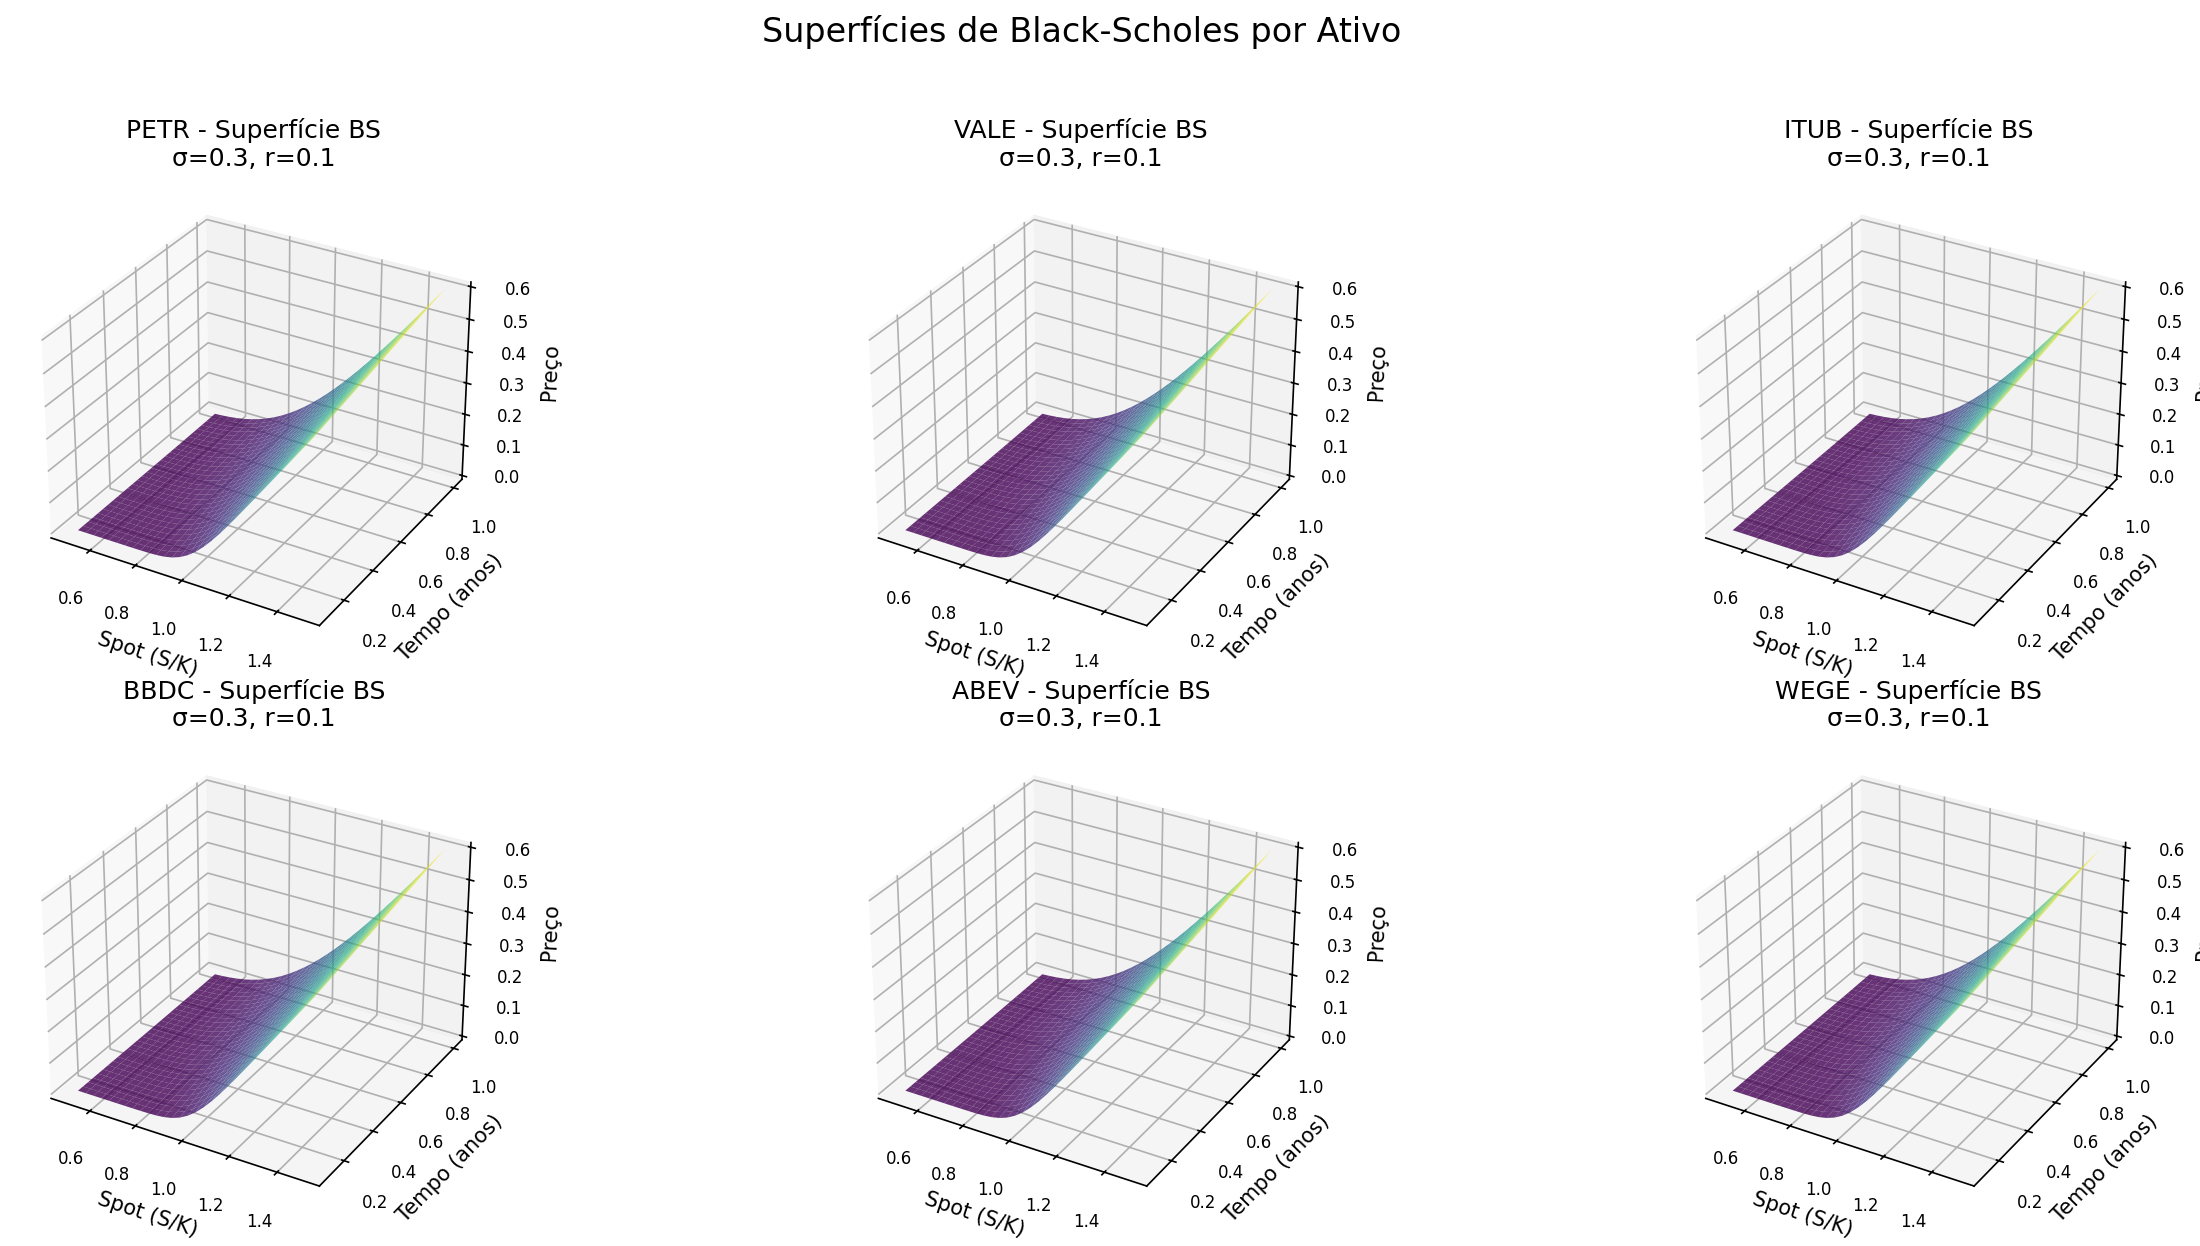

In [ ]:
#  10.2: Curvas 3D de Black-Scholes por Ativo

def plot_bs_surface_by_asset(model, dataset, data_stats, device, asset_names=None):
    """
    Gera superfície 3D tipo Black-Scholes para cada ativo.
    """
    from scipy.stats import norm
    
    def black_scholes_surface(S_grid, T_grid, K=1.0, r=0.1, sigma=0.3):
        """Calcula superfície de preços Black-Scholes."""
        S_grid = np.maximum(S_grid, 1e-5)
        T_grid = np.maximum(T_grid, 1e-5)
        
        d1 = (np.log(S_grid / K) + (r + 0.5 * sigma ** 2) * T_grid) / (sigma * np.sqrt(T_grid))
        d2 = d1 - sigma * np.sqrt(T_grid)
        
        price = S_grid * norm.cdf(d1) - K * np.exp(-r * T_grid) * norm.cdf(d2)
        return price
    
    if asset_names is None:
        asset_names = list(data_stats['asset_map'].keys())[:6]  # Limitar a 6 ativos
    
    n_assets = len(asset_names)
    n_cols = 3
    n_rows = (n_assets + n_cols - 1) // n_cols
    
    fig = plt.figure(figsize=(6*n_cols, 4*n_rows))
    
    for idx, asset_name in enumerate(asset_names):
        if idx >= n_assets:
            break
            
        # Gerar grid sintético
        S_vals = np.linspace(0.5, 1.5, 30)
        T_vals = np.linspace(0.1, 1.0, 30)
        S_grid, T_grid = np.meshgrid(S_vals, T_vals)
        
        # Calcular preços Black-Scholes
        bs_prices = black_scholes_surface(S_grid, T_grid)
        
        # Calcular preços do modelo para esse ativo
        # (Precisaríamos de uma função que gere preços do modelo para o grid)
        # Por enquanto, mostramos apenas BS
        
        ax = fig.add_subplot(n_rows, n_cols, idx+1, projection='3d')
        surf = ax.plot_surface(S_grid, T_grid, bs_prices, cmap='viridis', 
                               edgecolor='none', alpha=0.8)
        
        ax.set_xlabel('Spot (S/K)')
        ax.set_ylabel('Tempo (anos)')
        ax.set_zlabel('Preço')
        ax.set_title(f'{asset_name} - Superfície BS\nσ=0.3, r=0.1')
    
    plt.suptitle('Superfícies de Black-Scholes por Ativo', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(PATHS['model_save_dir'], 'bs_surfaces_by_asset.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()

# Executar para os principais ativos
print("\n" + "="*70)
print("GERANDO CURVAS 3D DE BLACK-SCHOLES POR ATIVO")
print("="*70)

# Selecionar 6 ativos principais
main_assets = ['PETR', 'VALE', 'ITUB', 'BBDC', 'ABEV', 'WEGE']
plot_bs_surface_by_asset(
    model_generalista,  # ✓ Usa o nome correto
    ds_2024,
    data_stats,
    device,
    main_assets
)

In [ ]:
#  11: Avaliação dos Modelos Especializados

print("\n" + "="*70)
print("AVALIAÇÃO DOS MODELOS ESPECIALIZADOS EM 2024")
print("="*70)

# DataFrame para armazenar métricas comparativas
comparison_data = []

for ativo in ativos:
    print(f"\n{'─'*60}")
    print(f"AVALIANDO: {ativo}")
    print(f"{'─'*60}")
    
    # Caminho do modelo especialista
    spec_model_path = os.path.join(PATHS['model_save_dir'], f'best_{ativo}.pt')
    
    if not os.path.exists(spec_model_path):
        print(f"  Modelo especialista não encontrado: {spec_model_path}")
        continue
    
    # Filtrar dataset apenas para este ativo
    asset_id = data_stats['asset_map'][ativo]
    idx_ativo = np.where(ds_2024.tensors[5].numpy() == asset_id)[0]
    
    if len(idx_ativo) == 0:
        print(f"  Nenhum dado de 2024 para {ativo}")
        continue
    
    subset = Subset(ds_2024, idx_ativo)
    loader_ativo = DataLoader(subset, batch_size=4096, shuffle=False)
    
    # Carregar modelo especialista
    try:
        model_spec = load_adaptive_model(DeepHestonHybrid, MODEL_CONFIG, data_stats, 
                                        spec_model_path, device)
    except Exception as e:
        print(f"  Erro ao carregar modelo especialista: {e}")
        continue
    
    # Avaliar modelo especialista
    results_spec = avaliar_modelo(model_spec, loader_ativo, data_stats, 
                                 device, f"Especialista {ativo}")
    
    resultados_especialistas[ativo] = results_spec
    
    # Avaliar modelo generalista no mesmo subset para comparação justa
    if 'model_generalista' in locals():
        results_gen_subset = avaliar_modelo(model_generalista, loader_ativo, data_stats,
                                           device, f"Generalista ({ativo})")
        
        # Calcular melhoria
        mae_improvement = ((results_gen_subset['metrics']['MAE'] - 
                          results_spec['metrics']['MAE']) / 
                         results_gen_subset['metrics']['MAE'] * 100)
        
        rmse_improvement = ((results_gen_subset['metrics']['RMSE'] - 
                           results_spec['metrics']['RMSE']) / 
                          results_gen_subset['metrics']['RMSE'] * 100)
        
        # Armazenar dados comparativos
        comparison_data.append({
            'Ativo': ativo,
            'Amostras': len(idx_ativo),
            'MAE_Gen': results_gen_subset['metrics']['MAE'],
            'MAE_Spec': results_spec['metrics']['MAE'],
            'RMSE_Gen': results_gen_subset['metrics']['RMSE'],
            'RMSE_Spec': results_spec['metrics']['RMSE'],
            'R2_Gen': results_gen_subset['metrics']['R2'],
            'R2_Spec': results_spec['metrics']['R2'],
            'Melhoria_MAE_%': mae_improvement,
            'Melhoria_RMSE_%': rmse_improvement,
            'Melhoria_R2': results_spec['metrics']['R2'] - results_gen_subset['metrics']['R2']
        })
        
        #print(f"\n  COMPARAÇÃO {ativo}:")
        #print(f"    MAE: Generalista {results_gen_subset['metrics']['MAE']:.4f} → "
              #f"Especialista {results_spec['metrics']['MAE']:.4f} "
              #f"({mae_improvement:+.2f}%)")
        #print(f"    RMSE: Generalista {results_gen_subset['metrics']['RMSE']:.4f} → "
              #f"Especialista {results_spec['metrics']['RMSE']:.4f} "
              #f"({rmse_improvement:+.2f}%)")
        
        # Verificar significância estatística
        errors_gen = results_gen_subset['predictions'] - results_gen_subset['targets']
        errors_spec = results_spec['predictions'] - results_spec['targets']
        
        # Teste t para diferença de médias
        if len(errors_gen) > 1 and len(errors_spec) > 1:
            t_stat, p_value = stats.ttest_ind(np.abs(errors_gen), np.abs(errors_spec))
            print(f"    Teste t (p-value): {p_value:.6f}")
            if p_value < 0.05:
                print(f"    → Diferença estatisticamente significativa (p < 0.05)")
            else:
                print(f"    → Diferença não estatisticamente significativa")
    
    # Liberar memória GPU
    del model_spec
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Criar DataFrame comparativo
if comparison_data:
    df_comparison = pd.DataFrame(comparison_data)
    print(f"\n{'='*70}")
    print("RESUMO COMPARATIVO: GENERALISTA VS ESPECIALISTAS")
    print(f"{'='*70}")
    
    # Ordenar por melhoria em MAE
    df_comparison = df_comparison.sort_values('Melhoria_MAE_%', ascending=False)
    
    #print("\nTabela de Comparação (ordenada por melhoria em MAE):")
    #print(df_comparison[['Ativo', 'Amostras', 'MAE_Gen', 'MAE_Spec', 
                         #'Melhoria_MAE_%', 'RMSE_Gen', 'RMSE_Spec', 
                         #'Melhoria_RMSE_%', 'R2_Gen', 'R2_Spec']].to_string(index=False))
#    
    ## Estatísticas gerais
    #print(f"\nESTATÍSTICAS GERAIS:")
    #print(f"  Melhoria média em MAE: {df_comparison['Melhoria_MAE_%'].mean():.2f}%")
    #print(f"  Melhoria média em RMSE: {df_comparison['Melhoria_RMSE_%'].mean():.2f}%")
    #print(f"  Ativos com melhoria positiva em MAE: "
          #f"{(df_comparison['Melhoria_MAE_%'] > 0).sum()}/{len(df_comparison)}")
    #print(f"  Ativos com melhoria positiva em RMSE: "
          #f"{(df_comparison['Melhoria_RMSE_%'] > 0).sum()}/{len(df_comparison)}")
    
    # Salvar resultados comparativos
    csv_path = os.path.join(PATHS['plot_save_dir'], 'comparacao_especialistas.csv')
    df_comparison.to_csv(csv_path, index=False)
    print(f"\n Resultados comparativos salvos em: {csv_path}")
    
    


AVALIAÇÃO DOS MODELOS ESPECIALIZADOS EM 2024

────────────────────────────────────────────────────────────
AVALIANDO: CSNA
────────────────────────────────────────────────────────────
Carregando modelo de: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\modelo_final\best_CSNA.pt
Detectado LSTM input_size no checkpoint: 10
  -> Configurado sem embeddings (10 features diretas)
  -> Reconstruindo Pricing Net com 5 camadas...
Camadas inesperadas: ['asset_embedding.weight']

AVALIAÇÃO: Especialista CSNA
Amostras avaliadas: 19,609
MAE: 1.2474
RMSE: 2.1193
R²: -0.0905
MAPE: 1681.70%
Erro Médio: -0.0227
Std Erro: 2.1192

AVALIAÇÃO: Generalista (CSNA)
Amostras avaliadas: 19,609
MAE: 1.2724
RMSE: 2.1660
R²: -0.1391
MAPE: 1642.54%
Erro Médio: -0.1118
Std Erro: 2.1632
    Teste t (p-value): 0.153494
    → Diferença não estatisticamente significativa

────────────────────────────────────────────────────────────
AVALIANDO: WEGE
────────────────────────────────────────────────────────────
Ca

In [ ]:
# Dataset de comparação

df_comparison

,Ativo,Amostras,MAE_Gen,MAE_Spec,RMSE_Gen,RMSE_Spec,R2_Gen,R2_Spec,Melhoria_MAE_%,Melhoria_RMSE_%,Melhoria_R2
8,ITUB,48176,2.198045,1.991906,3.160377,2.929239,-0.436562,-0.234117,9.378278,7.313624,0.202446
10,GGBR,26916,1.327826,1.240311,1.902962,1.791793,-0.741967,-0.544384,6.590918,5.841884,0.197582
1,WEGE,26209,3.575717,3.369282,4.826279,4.753492,-0.382712,-0.341321,5.773253,1.508123,0.041391
5,LREN,23311,1.718895,1.629193,3.257185,3.154308,-0.153603,-0.081882,5.218572,3.158470,0.071722
7,PETR,139892,4.499854,4.367202,6.910489,6.442413,-0.280652,-0.113040,2.947914,6.773408,0.167612
12,SUZB,28716,4.442163,4.315298,6.284797,6.149233,-3.171728,-2.993699,2.855916,2.157026,0.178030
3,VALE,96612,7.713205,7.519413,16.383823,16.140939,-0.966973,-0.909086,2.512463,1.482463,0.057887
13,BOVA,98701,14.941772,14.646629,21.698734,21.124411,-3.184517,-2.965937,1.975289,2.646802,0.218580
0,CSNA,19609,1.272423,1.247438,2.166049,2.119311,-0.139140,-0.090511,1.963554,2.157740,0.048629
11,BBDC,49828,1.270546,1.247348,2.446522,2.426114,0.045654,0.061508,1.825867,0.834134,0.015855


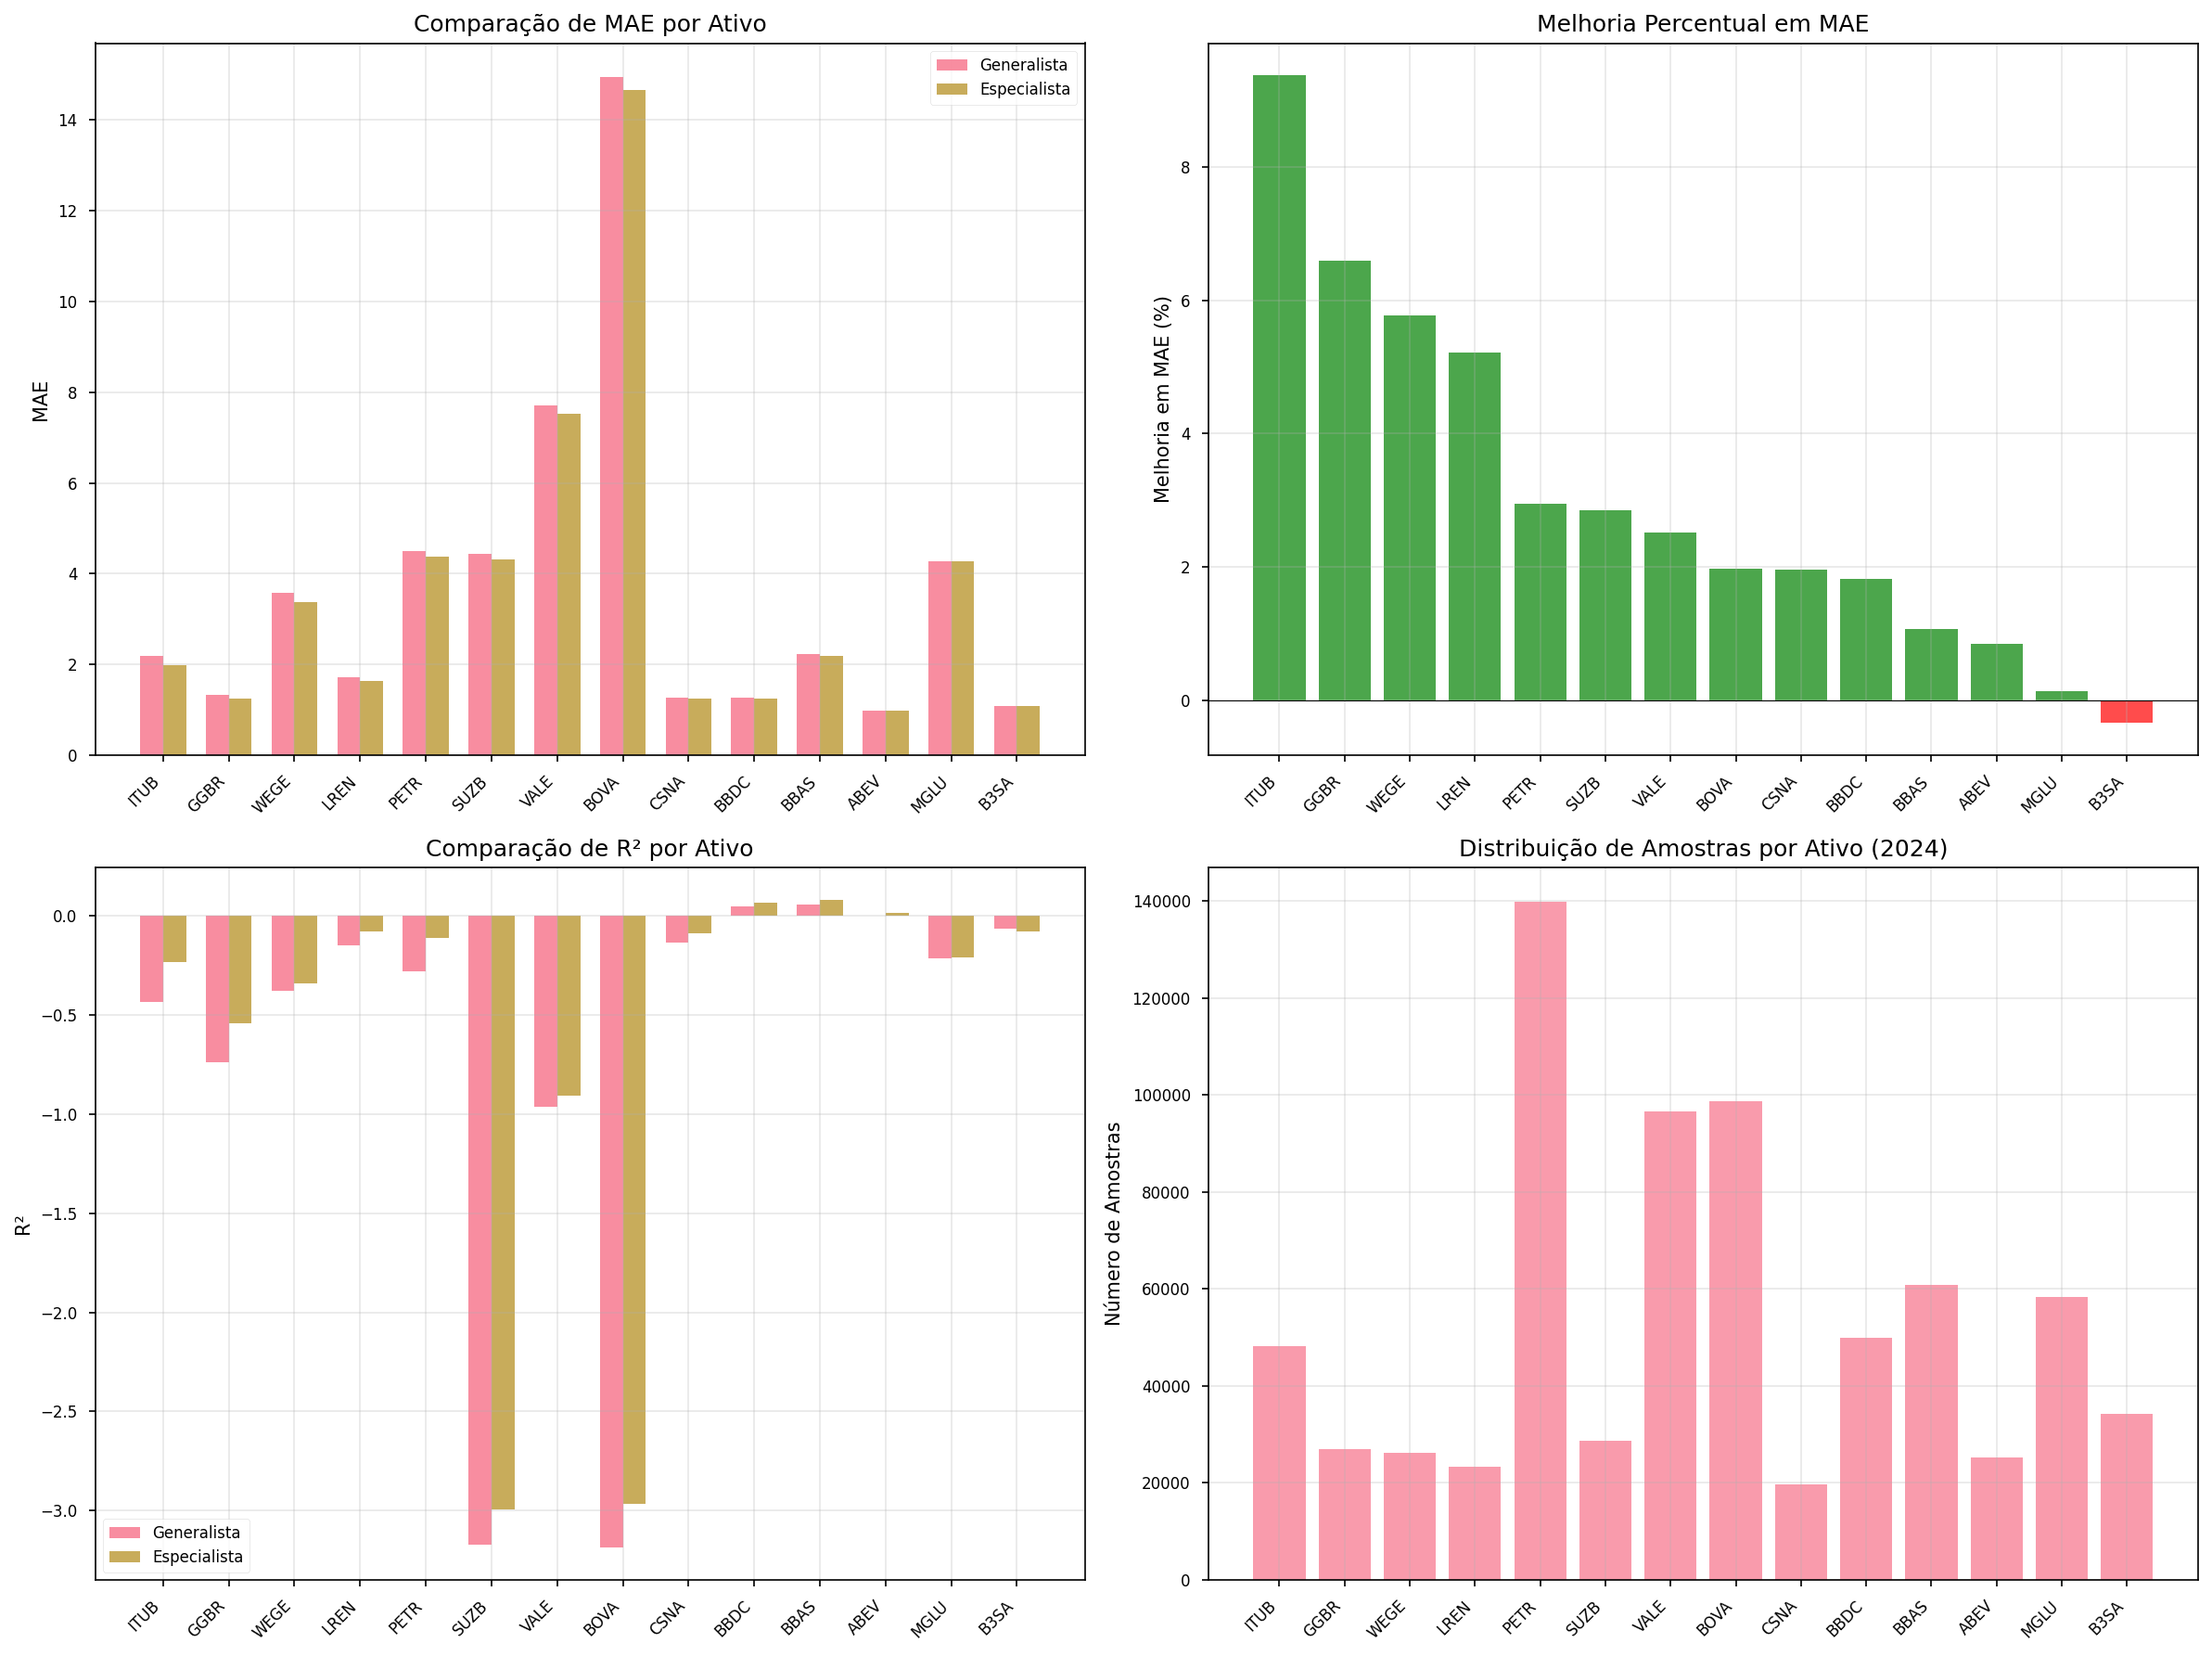

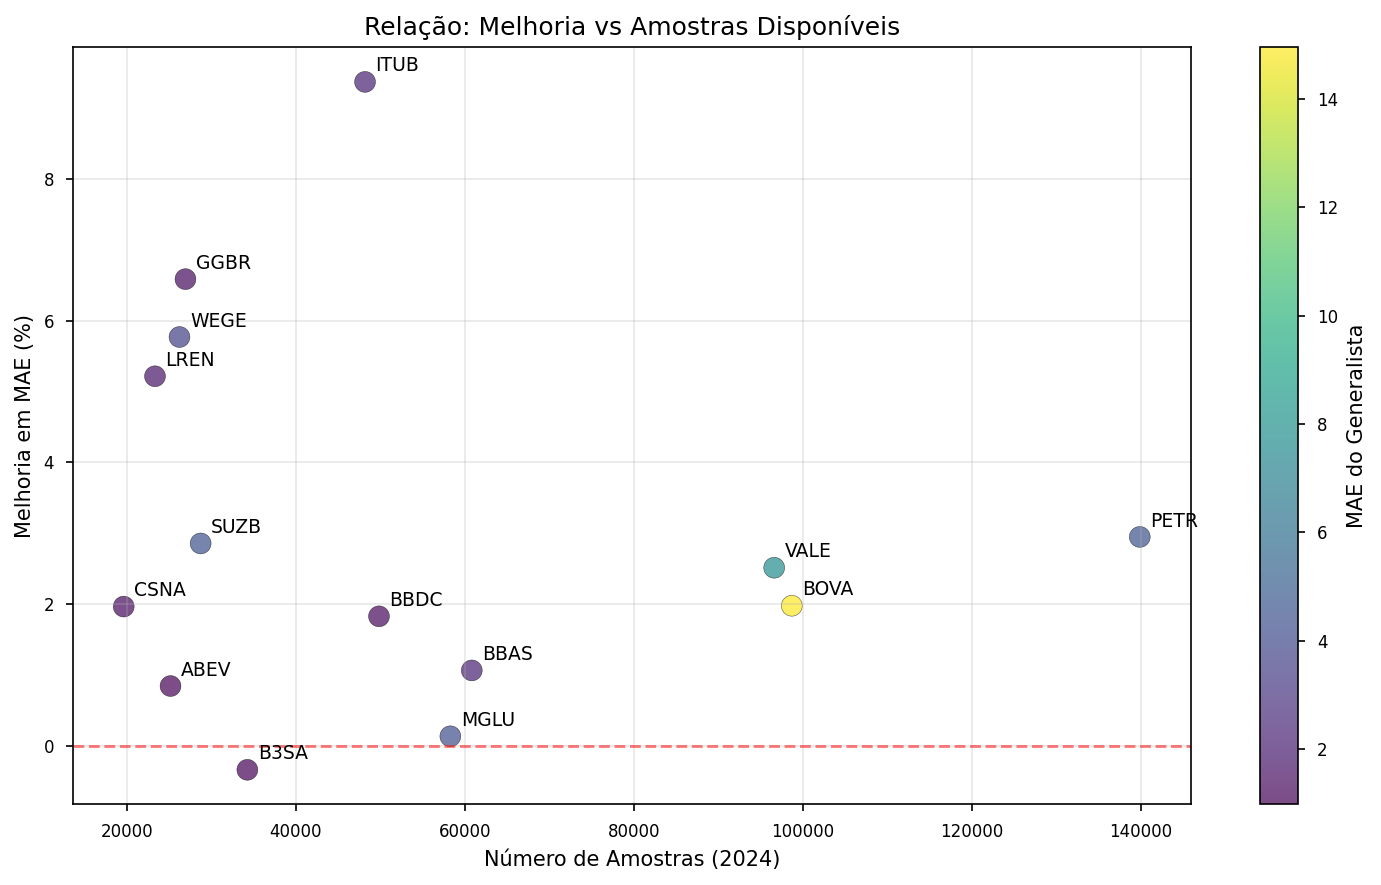

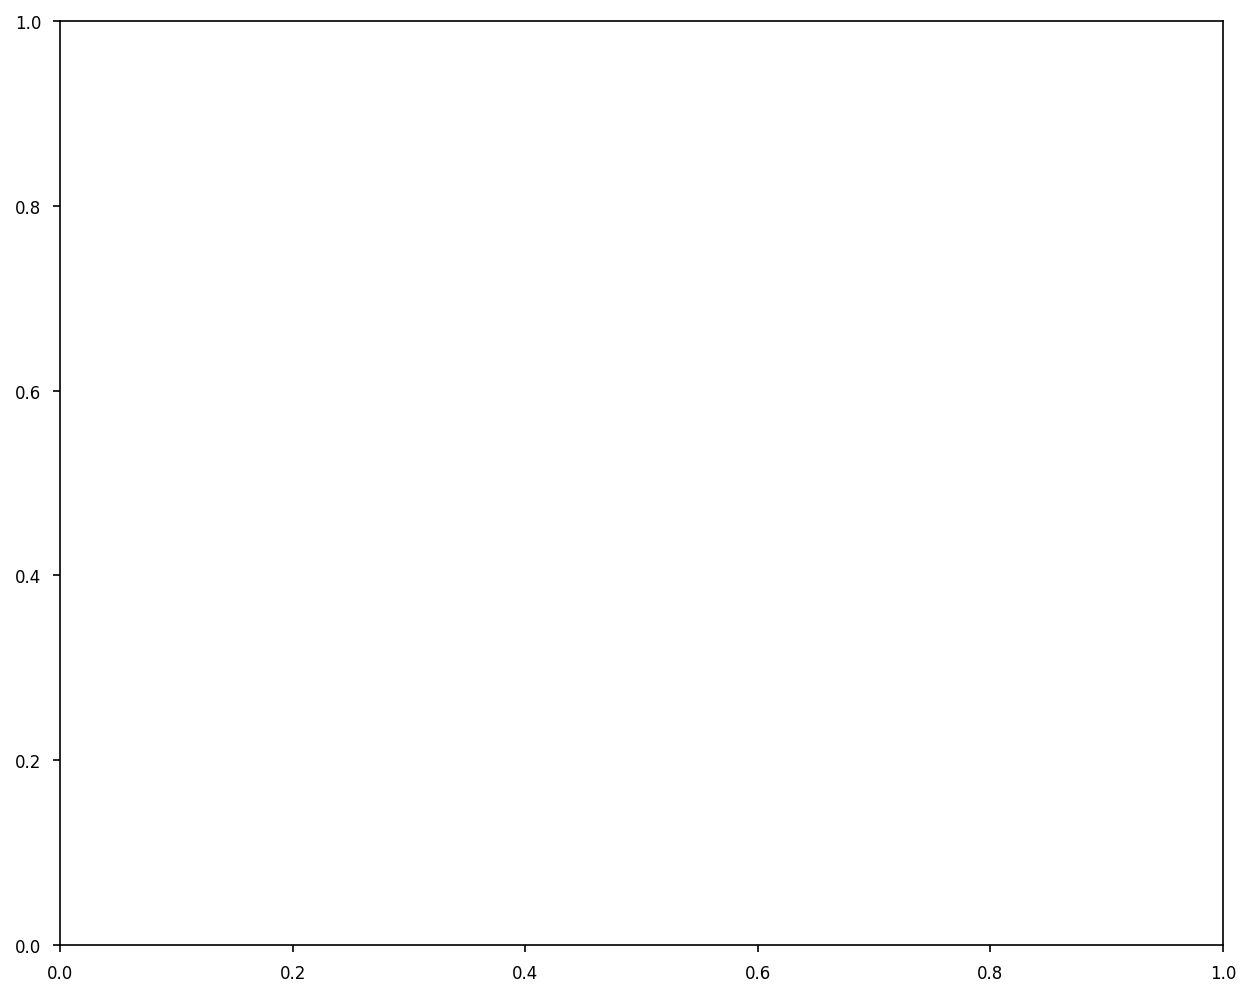

In [ ]:
#  12: Visualizações Comparativas

# 1. Gráfico de barras comparando MAE
if 'df_comparison' in locals() and len(df_comparison) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # MAE Comparação
    x = range(len(df_comparison))
    width = 0.35
    
    axes[0, 0].bar([i - width/2 for i in x], df_comparison['MAE_Gen'], 
                   width, label='Generalista', alpha=0.8)
    axes[0, 0].bar([i + width/2 for i in x], df_comparison['MAE_Spec'], 
                   width, label='Especialista', alpha=0.8)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(df_comparison['Ativo'], rotation=45, ha='right')
    axes[0, 0].set_ylabel('MAE')
    axes[0, 0].set_title('Comparação de MAE por Ativo')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Melhoria em MAE
    colors = ['green' if x > 0 else 'red' for x in df_comparison['Melhoria_MAE_%']]
    axes[0, 1].bar(x, df_comparison['Melhoria_MAE_%'], color=colors, alpha=0.7)
    axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(df_comparison['Ativo'], rotation=45, ha='right')
    axes[0, 1].set_ylabel('Melhoria em MAE (%)')
    axes[0, 1].set_title('Melhoria Percentual em MAE')
    axes[0, 1].grid(True, alpha=0.3)
    
    # R² Comparação
    axes[1, 0].bar([i - width/2 for i in x], df_comparison['R2_Gen'], 
                   width, label='Generalista', alpha=0.8)
    axes[1, 0].bar([i + width/2 for i in x], df_comparison['R2_Spec'], 
                   width, label='Especialista', alpha=0.8)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(df_comparison['Ativo'], rotation=45, ha='right')
    axes[1, 0].set_ylabel('R²')
    axes[1, 0].set_title('Comparação de R² por Ativo')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Distribuição de amostras
    axes[1, 1].bar(x, df_comparison['Amostras'], alpha=0.7)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(df_comparison['Ativo'], rotation=45, ha='right')
    axes[1, 1].set_ylabel('Número de Amostras')
    axes[1, 1].set_title('Distribuição de Amostras por Ativo (2024)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PATHS['model_save_dir'], 'comparacao_especialistas.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()
    
# 2. Scatter plot de melhoria vs número de amostras
if 'df_comparison' in locals() and len(df_comparison) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    scatter = ax.scatter(df_comparison['Amostras'], df_comparison['Melhoria_MAE_%'],
                        c=df_comparison['MAE_Gen'], cmap='viridis', 
                        s=100, alpha=0.7, edgecolors='black')
    
    # Adicionar labels
    for i, row in df_comparison.iterrows():
        ax.annotate(row['Ativo'], (row['Amostras'], row['Melhoria_MAE_%']),
                   xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Número de Amostras (2024)')
    ax.set_ylabel('Melhoria em MAE (%)')
    ax.set_title('Relação: Melhoria vs Amostras Disponíveis')
    ax.grid(True, alpha=0.3)
    
    # Colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('MAE do Generalista')
    
    plt.tight_layout()
    plt.savefig(os.path.join(PATHS['plot_save_dir'], 'relacao_melhoria_amostras.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

# 3. Heatmap de correlação entre métricas
if 'df_comparison' in locals() and len(df_comparison) > 0:
    metrics_corr = df_comparison[['MAE_Gen', 'MAE_Spec', 'RMSE_Gen', 'RMSE_Spec',
                                 'R2_Gen', 'R2_Spec', 'Amostras', 'Melhoria_MAE_%']].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
   